# Value-based Methods

Balancing **immediate** and **long-term goals** is challenging. We experience this tension every day: should I watch movies tonight, or keep studying reinforcement learning? The first choice gives us **immediate satisfaction**. The second may not give us much satisfaction tonight, but maybe (and only maybe) it will provide much **greater satisfaction in the long run**. But how much greater? We do not know, and we cannot know without trying it, without exploring. Life does not give us its MDP! We do not know exactly how our actions will affect the future, and even the same action may lead to different outcomes. This brings together the two fundamental challenges we have studied so far. We must **balance information gathering and information utilization**, while at the same time **reasoning about the long-term consequences** of our actions rather than only their immediate effects. In other words, we must deal simultaneously with exploration versus exploitation and immediate versus long-term reward.

We will now study agents that can learn to estimate the value of policies, much like the policy-evaluation methods we encountered in dynamic programming, but with one crucial difference: this time, the agent does not know the MDP. It must learn values from experience.

Before doing so, let us revisit three closely related but fundamentally different concepts:

* The reward is the one-step feedback signal received from the environment. The agent observes a state, selects an action, and receives a reward. Rewards tell us what is good immediately, but maximizing the reward received at each individual step is not the objective of reinforcement learning. A greedy pursuit of immediate reward can sacrifice much larger rewards available later.
* The return is the accumulated discounted reward from a given time onward. Unlike a single reward, it captures the long-term consequences of a sequence of decisions. However, in a stochastic environment, the return itself is a random variable. The same policy, starting from the same state, may produce a very high return in one episode and a very low return in another. Therefore, optimizing for one particular realized return is not enough.
* The value function captures what we really need: the expected return. It tells us how much discounted reward we can expect to accumulate in the future, on average, when following a particular policy. Random transitions and stochastic policies are therefore naturally accounted for: individual trajectories may differ, but their expected return defines the value.

The central idea is therefore simple:

The agent is not trying to maximize the immediate reward, nor a single realized return. It is trying to find behavior that maximizes the expected return — and value functions allow us to reason about exactly that quantity.

This also sets up the transition to Monte Carlo and TD methods particularly well: Dynamic Programming computes values from a known model, whereas the next methods will learn estimates of those values from sampled experience. Sutton and Barto explicitly identify efficient value estimation as a central component of RL algorithms. Reinforcement Learning - An Introduction.pdf

## Policy Evaluation

We first assume the policy is **fixed** and ask only: how good is it? Estimating $v_\pi$ from sampled experience, without a model, is the *prediction* problem. Monte Carlo, TD(0), $n$-step TD and TD($\lambda$) are four answers that differ in how much real reward they wait for before bootstrapping.

### Random Walk Environment

A single-row grid-world environment, with five non-terminal states. The probability of going left when taking the "left" action is equal to the probability of going right, and the probability of going right when taking the "right" action is equal to the probability of going left. In other words, **the agent has no control of where it goes**. This environment is useful **to focus on the prediction problem**, in which there is no need to distinguish the dynamics due to the environment from those due to the agent. 

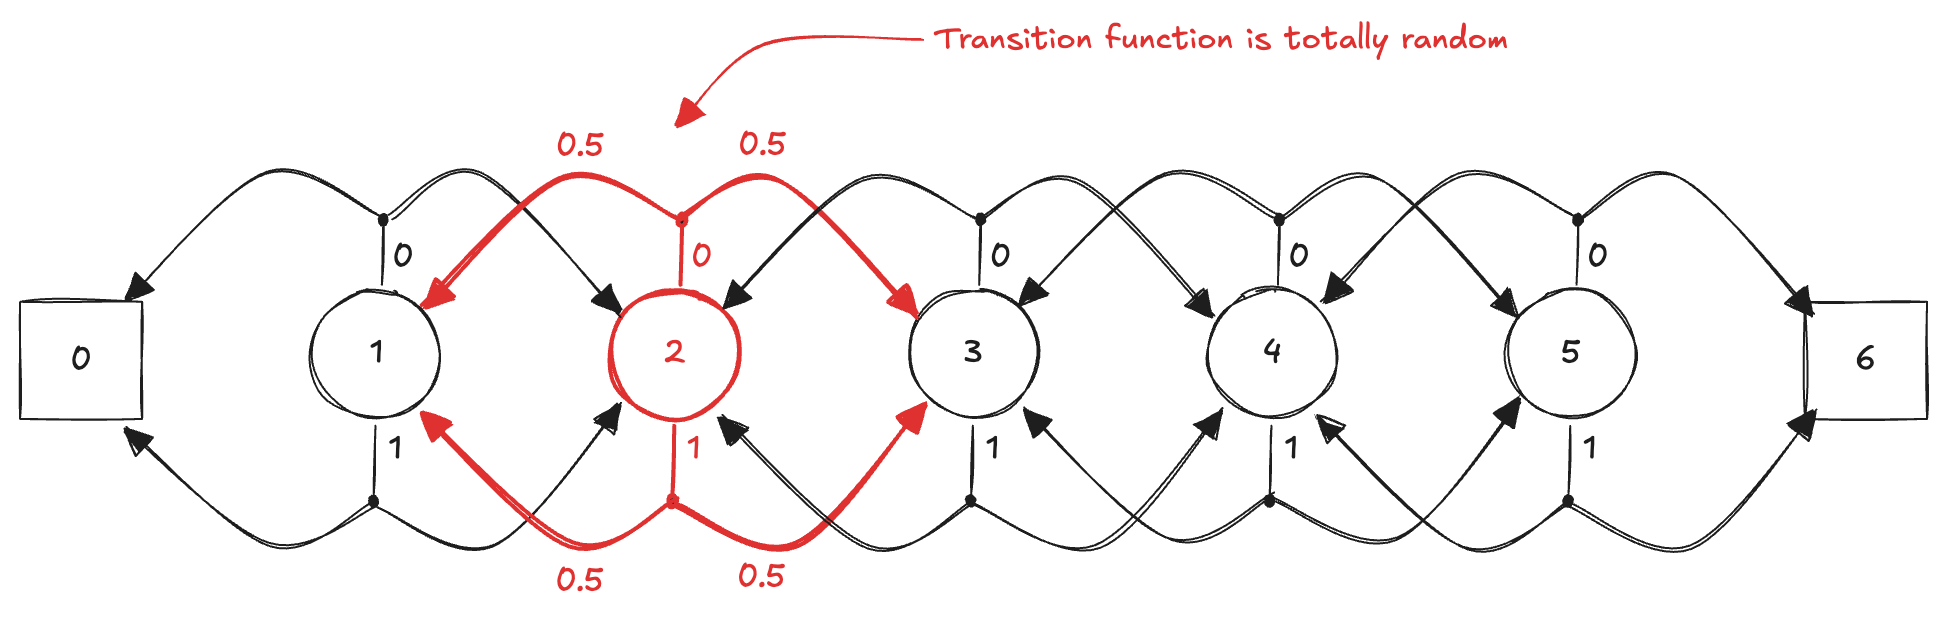

In [1]:
import numpy as np
    
class RandomWalk:
    """
    State Index:   [ 0    1    2    3    4    5    6 ]
    State Label:   [ .    A    B    C    D    E    . ]
    Type:          [ T    .    .    S    .    .    T ]    
    """
    v_true =       [0.0, 1/6, 2/6, 3/6, 4/6, 5/6, 0.0]
    
    def __init__(self):
        self.reset()

    def reset(self):
        self.observation_space = 7
        self.state = np.random.choice([1,2,3,4,5])
        self.terminated = False
        return self.state

    def step(self, action):     
        self.state += np.random.choice([-1, 1])
        
        reward = 0
        
        if self.state < 1: 
            self.terminated = True
        
        if self.state > 5: 
            self.terminated = True; 
            reward = 1
        
        return self.state, reward, self.terminated, 0, 0  # obs, rew, terminated, truncated, info

In [2]:
random_walk = RandomWalk()

The dynamics of this environment make policy being evaluated irrelevant, so we select an all-left policy:

In [3]:
def pi(state):
    return 1

### Improving estimates after each episode: Monte Carlo

The goal is to estimate the state-value function of a policy (the expectation of returns): 

$\displaystyle v_{\pi}(s) = E_{\pi}[G_{t:T} | S_t=s]$

The most straightforward approach that comes to mind is **to run several episodes** with the policy under evaluation, **collecting hundreds of trajectories** (collections of **experiences** like [state, action, reward, next state]) and then **calculate averages** for every state. 

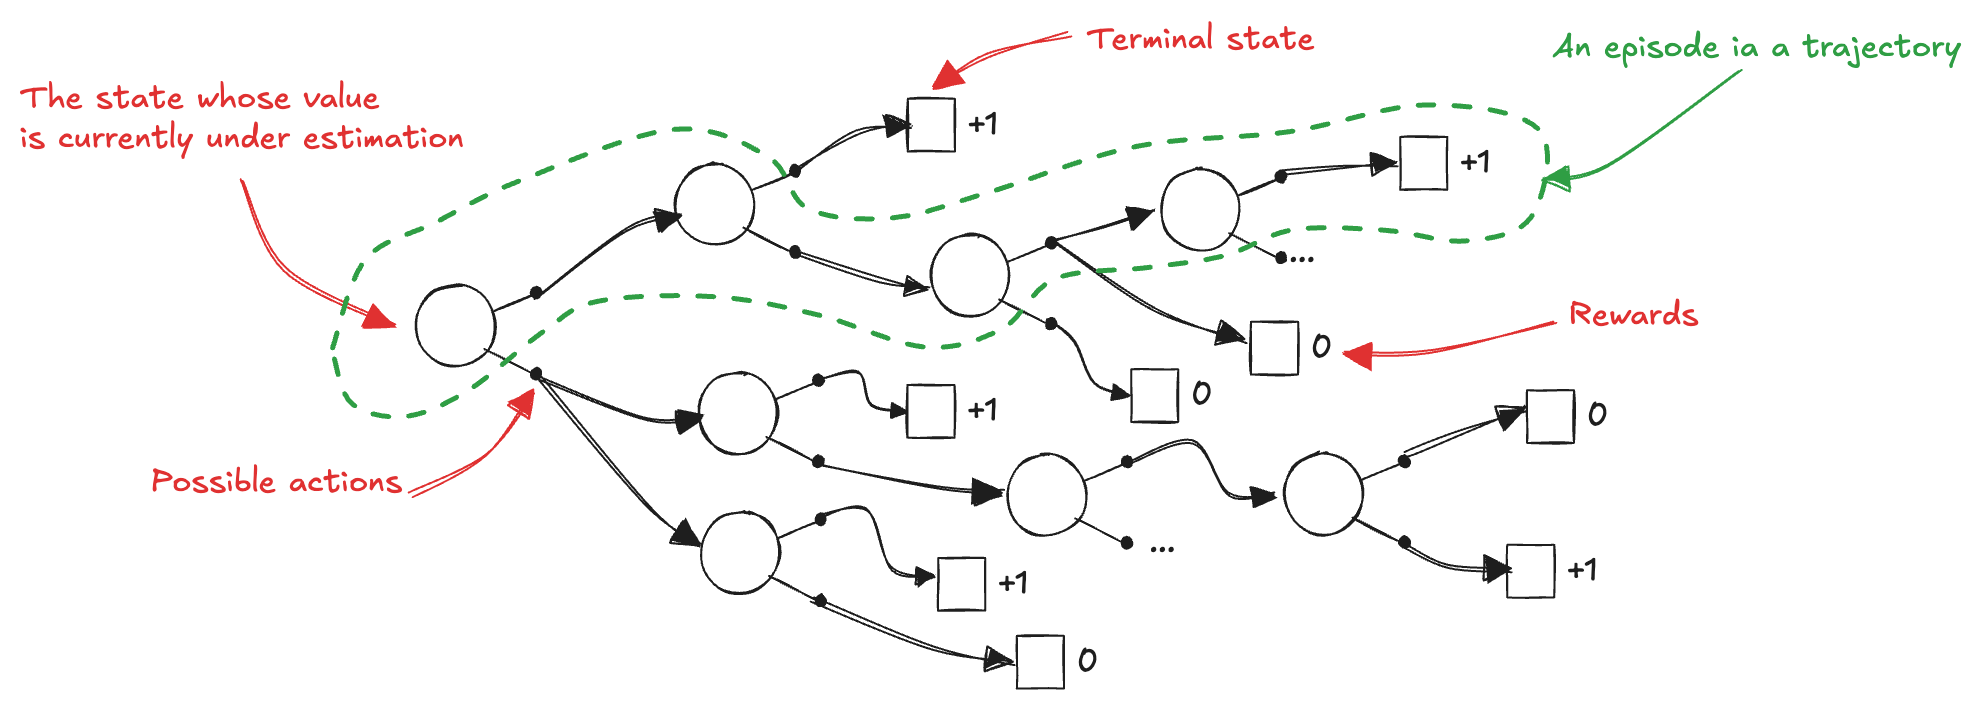

This method is called **Monte Carlo prediction (MC)** and it is easy to implement. Given a trajectory:

$\displaystyle S_t, A_t, R_{t+1}, S_{t+1}$

$\displaystyle S_{t+1}, A_{t+1}, R_{t+2}, S_{t+2}$

$\displaystyle ...$

$\displaystyle S_{T-1}, A_{T-1}, R_T, S_T$

We calculate the return for every state encountered by adding and discounting the rewards received along the way, until the end of the trajectory at time step T: 

$\displaystyle G_{t:T} = R_{t+1} + \gamma R_{t+2} + ... + \gamma^{T-1}R_T$

Then, add up the per-state returns and increment a count:

$\displaystyle T(S_t) = T(S_t) + G_{t:T}$

$\displaystyle N(S_t) = N(S_t) + 1$

Finally, we can estimate the expectation using the empirical mean:

$\displaystyle V(S_t) = \frac{T(S_t)}{N({S_t})}$

As the counts approach infinity, the estimate will approach the true value:

$\displaystyle N(s) \longrightarrow \infty \Rightarrow V(s) \longrightarrow v_{\pi}(s)$

Notice that means can be calculated incrementally, there’s no need to keep track of the sum of returns for all states. This equation is equivalent and more efficient:

$\displaystyle V(S_t) = V(S_t) + \frac{G_{t:T} - V(S_t)}{N({S_t})}$

On this, we can replace the mean for a learning value that can be time dependent or constant:

$\displaystyle V_{k-1}(S_t) = V_k(S_t) + \alpha_t [G_{t:T} - V_k(S_t)]$

Where $G_{t:T}$ is the **MC target** and $G_{t:T} - V(S_t)$ is the **MC error**. Notice that V is calculated only at the end of an episode, because the returns depends on it. In practice, there are two different ways of implementing the algorithm. A single trajectory **may contain multiple visits to the same state**. Should we calculate the returns following each of those visits independently and then **include all** of those targets in the averages, or should we only use the **first visit** to each state? Both are valid approaches, and they have similar theoretical properties. The more standard version is **first-visit Monte Carlo (FVMC)**, and its convergence properties are easy to justify. **Every-visit Monte Carlo (EVMC)** is slightly different but has also been proven to converge given infinite samples. 

We can implement this method in Python. First of all, we write a function in order to calculate an exponentially decaying schedule to calculate all the values for alpha for the full process, we use the NumPy "logspace" function that returns evenly spaced numbers on a log scale. This hyperparameter is essential. **Often, alpha is a positive constant less than 1**. Having **a constant alpha helps with learning in non-stationary environments**. However, we can decay alpha in order to **show convergence**: alpha starts at a value, then it decreases exponentially to a min value in a number of episodes out of the total episodes. In that way alpha helps the algorithms get close to converging, but because alpha don't goes to zero, they don’t fully converge. We will use the same schedule in all algorithms.

In [8]:
import numpy as np

def decay_alpha(init_value, min_value, decay_steps, max_steps):

    # calculate the number of the remaining steps after the decay
    rem_steps = max_steps - decay_steps
    
    # logspace returns numbers spaced evenly on a log scale
    # base^start is the starting value of the sequence,
    # base^stop is the final value of the sequence
    # num is the number of values to generate
    # base is the base of the log space
    values = np.logspace(start=0, stop=-2, num=decay_steps, base=10)
    
    # because the values may not end exactly at 0, given it’s the log, 
    # we change them to be between 0 and 1 so that the curve looks smooth and nice.
    values = (values - values.min()) / (values.max() - values.min())
    
    # linear transformation and get points between init_value and min_value
    values = (init_value - min_value) * values + min_value
    
    # repeats the rightmost value rem_step number of times
    values = np.pad(values, (0, rem_steps), 'edge')
    
    return values

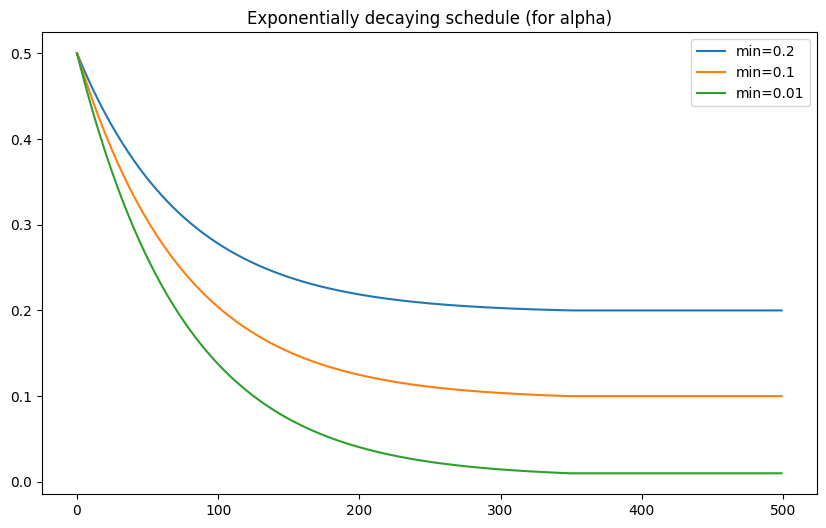

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(decay_alpha(0.5, 0.2, 350, 500), label='min=0.2')
plt.plot(decay_alpha(0.5, 0.1, 350, 500), label='min=0.1')
plt.plot(decay_alpha(0.5, 0.01, 350, 500), label='min=0.01')
plt.title('Exponentially decaying schedule (for alpha)')
plt.legend()
plt.show()

We need to discount the rewards collected during a trajectory with an exponentially decaying discount factor ($\gamma^0$ , $\gamma^1$ , $\gamma^2$,...), so we can reuse the "linspace" function to calculate all the discount values for the full process:

In [10]:
def decay_discounts(gamma, max_steps):
    discounts = np.logspace(start=0, stop=max_steps, num=max_steps, base=gamma, endpoint=False);
    return discounts

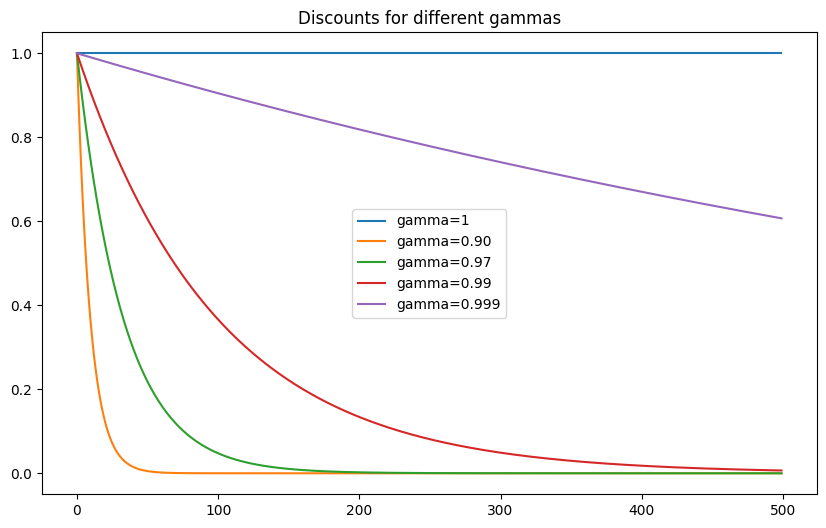

In [11]:
plt.figure(figsize=(10,6))
plt.plot(decay_discounts(1, 500), label='gamma=1')
plt.plot(decay_discounts(0.90, 500), label='gamma=0.90')
plt.plot(decay_discounts(0.97, 500), label='gamma=0.97')
plt.plot(decay_discounts(0.99, 500), label='gamma=0.99')
plt.plot(decay_discounts(0.999, 500), label='gamma=0.999')
plt.title('Discounts for different gammas')
plt.legend()
plt.show()

Then we write a function to run a policy over an environment and to extract a trajectory:

In [12]:
def generate_trajectory(pi, env, max_steps=200):
    
    # list of experiences (trajectory)
    trajectory = []
    
    done = False
    steps = 0
    
    # reset the environment to interact in a new episode
    state = env.reset()

    # looping through until the done flag is set to true
    while not done:     
        steps += 1;   

        # use the policy function to pick an action
        action = pi(state) 
            
        # step the environment using that action 
        next_state, reward, terminated, truncated, info = env.step(action)
        if(terminated or truncated):
            done = True;
        
        # append the experience to the trajectory
        experience = (state, action, reward, next_state, done)
        trajectory.append(experience)
            
        # if we hit a terminal state break and return
        if done:
            break;
                
        # truncate long trajectories
        if steps >= max_steps:
            break;
            
        # update the state
        state = next_state
            
    # return the trajectory
    return np.array(trajectory, object)

Now we can write the MC prediction function using the first-visit version:

In [ ]:
def mc(pi, env, gamma=1.0, init_alpha=0.5, min_alpha=0.01, decay_episodes=350, n_episodes=500, max_steps=200):
    # calculate all discounts at once 
    discounts = decay_discounts(gamma, max_steps);
    
    # calculate all alphas at once
    alphas = decay_alpha(init_alpha, min_alpha, decay_episodes, n_episodes);
    
    # initialize the current estimate of the state-value function
    v = np.zeros(env.observation_space, dtype=float)
    
    # create a list to save copies of v for offline analysis
    v_track = np.zeros((n_episodes, env.observation_space), dtype=float)
    
    # loop for every episode 
    for e in range(n_episodes):
        
        # generate a trajectory
        trajectory = generate_trajectory(pi, env, max_steps)
        
        # initialize a visits check vector
        visited = np.zeros(env.observation_space, dtype=bool)
        
        # loop through all experiences in the trajectory
        for t, (state, _, reward, _, _) in enumerate(trajectory):
            
            # check if the state has already been visited
            if visited[state]: 
                continue;
            visited[state] = True
            
            # calculate the number of steps from t to T
            n_steps = len(trajectory[t:])
            
            # calculate the return
            g = np.sum(discounts[:n_steps] * trajectory[t:, 2])
            
            # estimate the value function
            mc_target = g
            mc_error = mc_target - v[state]
            v[state] = v[state] + alphas[e] * mc_error
        
            # keep track of the episode V
            v_track[e] = v;
            
    return v.copy(), v_track

We can use the Monte Carlo prediction algorithm and show the estimates over episodes on the Random Walk environmet:

In [19]:
v_mc, v_mc_track = mc(pi, random_walk, n_episodes=500);

In [20]:
print(v_mc)

[0.         0.13701912 0.33570019 0.53337701 0.70333317 0.87791777
 0.        ]


In [21]:
print(random_walk.v_true)

[0.0, 0.16666666666666666, 0.3333333333333333, 0.5, 0.6666666666666666, 0.8333333333333334, 0.0]


We can plot the estimates for the Random Walk environment for some of the states during the process:

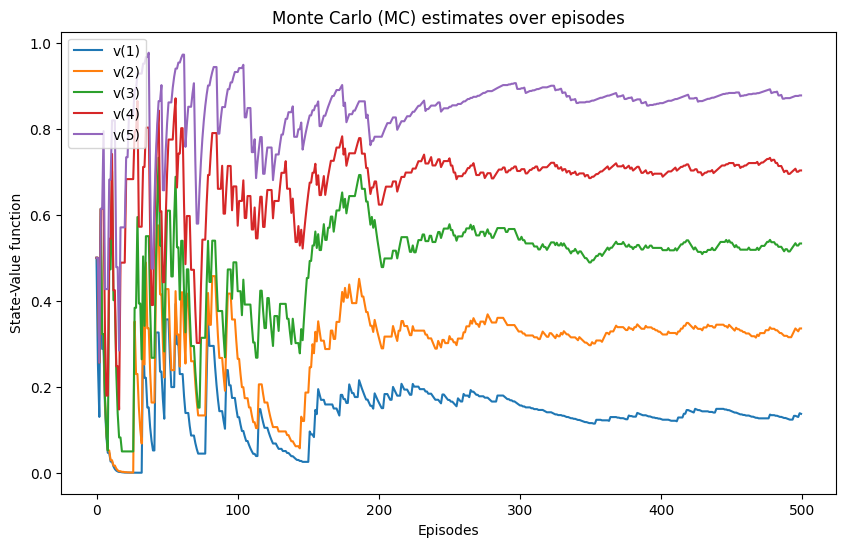

In [22]:
plt.figure(figsize=(10,6))
legends = ['v(1)','v(2)','v(3)','v(4)','v(5)']
plt.plot(v_mc_track[:,1:6])
plt.title('Monte Carlo (MC) estimates over episodes')
plt.ylabel('State-Value function')
plt.xlabel('Episodes')
plt.legend(legends)
plt.show()

The algorithm shows near-convergence to the true values. However, its **running estimates are very noisy**, they jump back and forth around the true values. We can run an experiment to calculate the **learning curve** to measure the performance using the root mean-squared (RMS) error between the value function learned and the true value function, averaged over the five states, then averaged over 100 runs:

In [48]:
from collections import defaultdict

def run_experiment(algorithm, runs, env, pi):
    v_runs = []
    for i in range(runs):
        _, v_td_track = algorithm(pi, env)
        v_runs.append(v_td_track)
    v_runs = np.array(v_runs) 
    
    # remove data about terminal states (which is always zero anyway)
    v_runs = v_runs[:,:,1:-1]  

    error_to_true = v_runs - env.v_true[1:-1]
    squared_error = np.power(error_to_true, 2)
    mean_squared_error = np.average(squared_error, axis=-1)
    root_mean_squared_error = np.sqrt(mean_squared_error)
    rmse_avg_over_runs = np.average(root_mean_squared_error, axis=0)
    
    return rmse_avg_over_runs

In [49]:
rmse_mc = run_experiment(mc, 100, random_walk, pi)

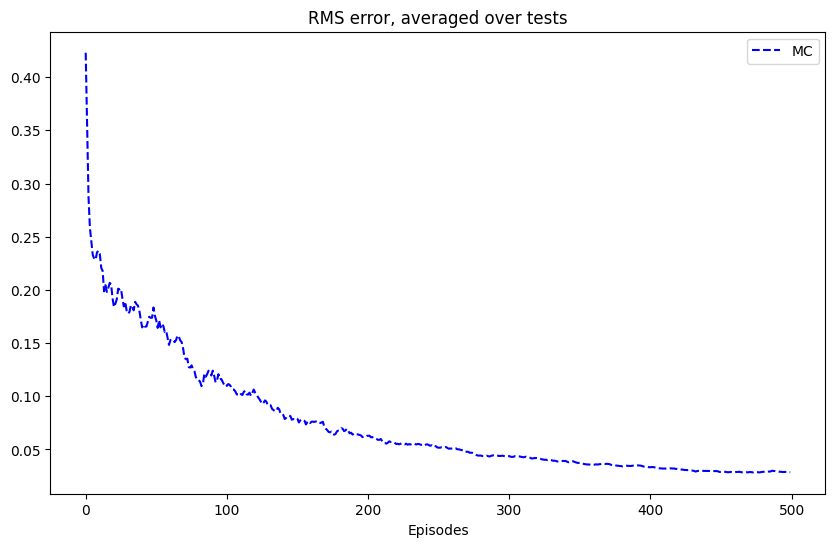

In [50]:
plt.figure(figsize=(10,6))
plt.plot(rmse_mc, color='blue', linestyle='--', label='MC')
plt.title('RMS error, averaged over tests')
plt.xlabel('Episodes')
plt.legend()
plt.show()

### Improving estimates after each step: Temporal-Difference Learning

MC has solid convergence properties, because it updates the value function estimate using the actual return, which is an unbiased estimate, however **the agent has to wait until the end of an episode** (when it obtain the return) before it can update the state-value function estimate, and this is a limitation. Moreover, the **actual returns are high-variance estimates** as they accumulate many random events in the same trajectory. All actions, all next states, all rewards are random events. The single return collects and compounds all of that randomness for multiple time steps (from t to T). So, **the single return is unbiased, but it has an high variance**. All of that randomness becomes noise that can only be alleviated with lots of trajectories. One way to diminish these issues of high variance and time is **to estimate a return instead of waiting for the actual value**. Notice that the agent is already calculating an estimate of the state-value function, so we can use a single-step reward and, once we observe the next state, we can use the current state-value function as an estimate of the return at the next step. 

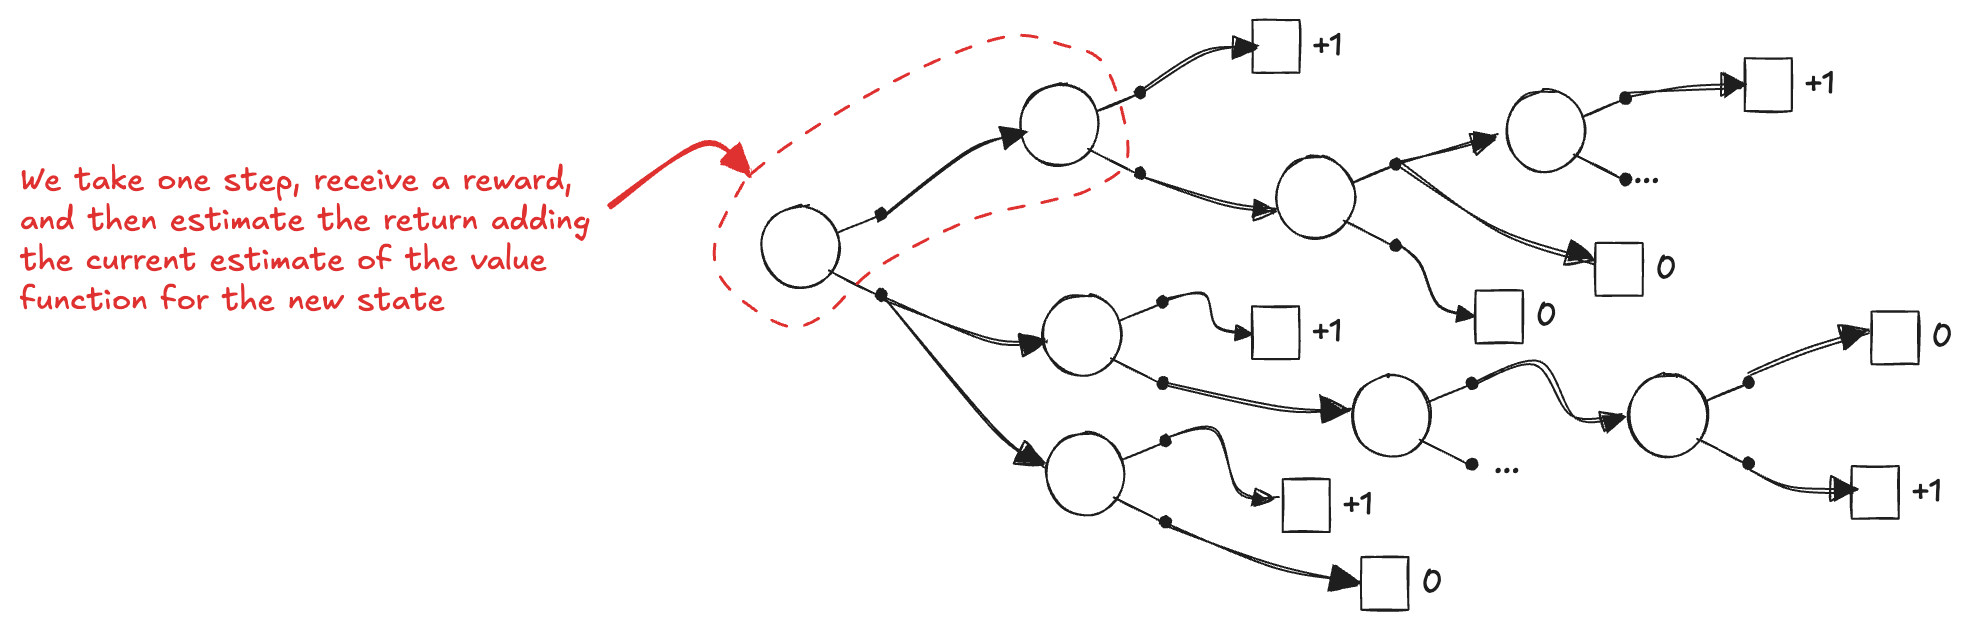

This is the relationship in the equations that **temporal-difference (TD) methods** exploit:

$\displaystyle G_{t:T} = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + ... + \gamma^{T-1} R_T$

$\displaystyle = R_{t+1} + \gamma (R_{t+2} + \gamma R_{t+3} + ... + \gamma^{T-2} R_T)$

$\displaystyle = R_{t+1} + \gamma G_{t+1:T}$

This means **we could estimate the return on every time step**. In order to make explict that we are using a single reward and then an estimate, we can use the subscript:

$\displaystyle G_{t:t+1} = R_{t+1} + \gamma V(S_{t+1})$

We can substitute in the formula for the evaluation of the state-value function:

$\displaystyle V(S_t) = V(S_t) + \alpha_t [G_{t:t+1} - V(S_t)]$

where $G_{t:t+1}$ is the **TD target** and $G_{t:t+1} - V(S_t)$ is the **TD error**. In other words, **TD methods estimate the state-value function using an estimate of the state-value function**. That reward signal **progressively "injects reality" into the estimates**. This way of **updating an estimate with an estimate** is referred to as **bootstrapping**. The TD estimate depends only on a single action, a single transition and a single reward, so there’s **much less randomness** being accumulated. As a consequence, TD methods usually learn **much faster** than MC methods. It can be seen as a **combination of Monte Carlo and Dynamic Programming ideas**. Like Monte Carlo, it learn directly from raw experience without a model of the environment’s dynamics. Like dynamic programming, it update estimates based in part on other learned estimates, without waiting for a final outcome. Dynamic Programming bootstraps on the one-step expectation while TD methods bootstrap **on a sample** of the one-step expectation. That word sample makes a whole lot of a difference. We can write the temporal-difference algorithm in Python: 

In [23]:
def td(pi, env, gamma=1.0, init_alpha=0.5, min_alpha=0.01, decay_episodes=350, n_episodes=500):

    # initialize the variables needed
    v = np.zeros(env.observation_space, dtype=float)
    v_track = np.zeros((n_episodes, env.observation_space), dtype=float)
    
    # calculate the learning rate schedule for all episodes
    alphas = decay_alpha(init_alpha, min_alpha, decay_episodes, n_episodes);
    
    # loop for n_episodes
    for e in range(n_episodes):
        
        # get the initial state and then enter the interaction loop
        state, done = env.reset(), False
        
        # get into the time step loop
        while not done:
            
            # sample the policy pi for the action to take in state
            action = pi(state)
            
            # use the action to interact with the environment... 
            # roll out the policy one step
            next_state, reward, terminated, truncated, info = env.step(action)
            if(terminated or truncated):
                done = True;
            
            # update the state value function
            td_target = reward + gamma * v[next_state] * (not done)
            td_error = td_target - v[state]
            v[state] = v[state] + alphas[e] * td_error
            
            # update the state variable for the next iteration
            state = next_state
            
        v_track[e] = v
        
    return v, v_track

Now we use the Temporal-Difference approach on the Random Walk environment:

In [24]:
v_td, v_td_track = td(pi, random_walk, n_episodes=500)

In [25]:
print(v_td)

[0.         0.14078207 0.30959484 0.47649427 0.64966111 0.8230806
 0.        ]


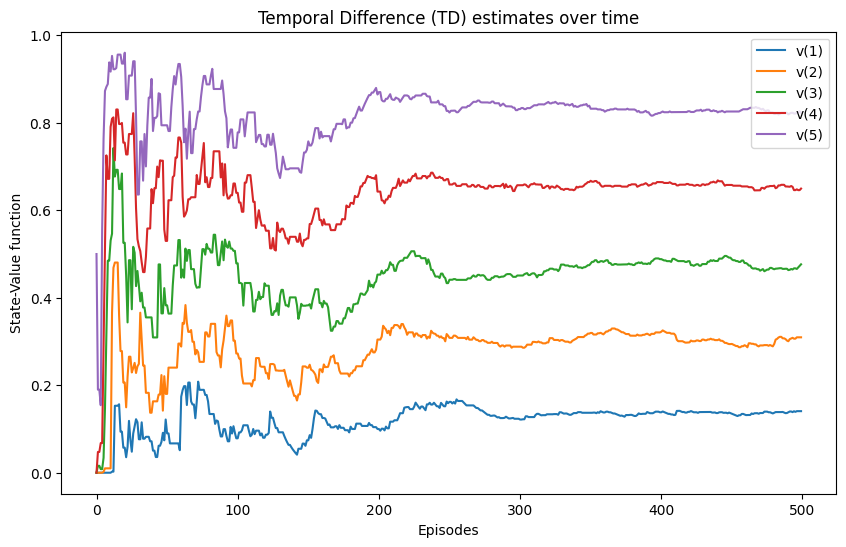

In [26]:
plt.figure(figsize=(10,6))
plt.plot(v_td_track[:,1:6])
plt.title('Temporal Difference (TD) estimates over time')
plt.ylabel('State-Value function')
plt.xlabel('Episodes')
plt.legend(legends)
plt.show()

While MC running estimates are very noisy, TD running estimates don’t jump as much, but they are off-center for most of the episodes.

In [55]:
rmse_td = run_experiment(td, 100, random_walk, pi)

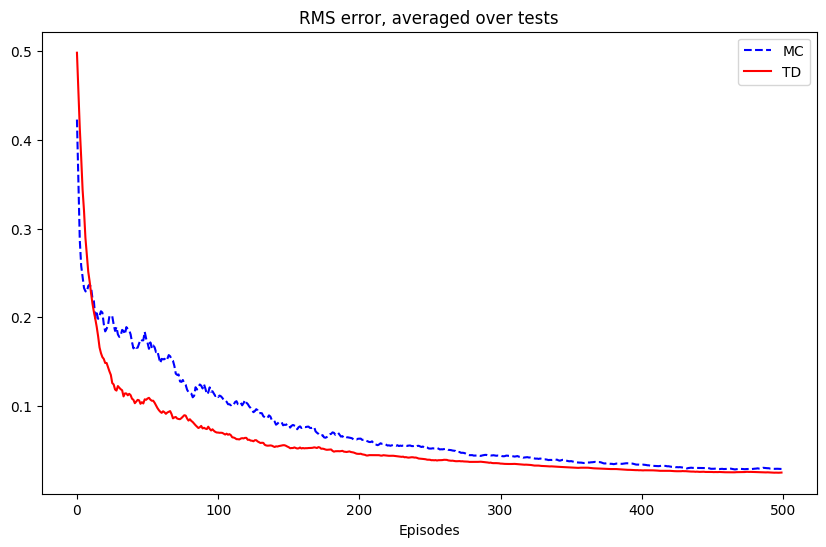

In [56]:
plt.figure(figsize=(10,6))
plt.plot(rmse_mc, color='blue', linestyle='--', label='MC')
plt.plot(rmse_td, color='red', linestyle='-', label='TD')
plt.title('RMS error, averaged over tests')
plt.xlabel('Episodes')
plt.legend()
plt.show()

At the beginning, both MC and TD methods start with a high error, indicating that the initial estimates of the value function are far from accurate. TD converges faster than MC, its line drops more rapidly in the first few episodes compared to the other. This indicates that TD is more efficient at reducing the error in the early stages of learning. As the number of episodes increases, both methods continue to reduce the error, but TD consistently performs better than MC. The TD line remains lower than the MC line throughout all the episodes, indicating that TD produces more accurate value function estimates on average. TD also appears to be more stable, with fewer fluctuations in error compared to MC, especially after the initial episodes. This suggests that TD might be better at handling noise in the learning process. Overall, the graph demonstrates that TD prediction is more efficient and effective than MC prediction in this scenario, leading to faster and more accurate convergence of the value function estimates.

### Batch updating

Suppose there is available only a **finite amount of experience**. In this case, a common approach is to **present the experience repeatedly** until the method converges upon an answer. We call this **batch updating** because updates are made only after processing each complete batch of training data. Under batch updating, TD and MC methods both converge but to **different answers**. Understanding these two answers will help us understand the difference between the two methods. Suppose we observe the following eight episodes:

- Episode 1: A, 0, B, 0 
- Episode 2: B, 1
- Episode 3: B, 1 
- Episode 4: B, 1
- Episode 5: B, 1 
- Episode 6: B, 1
- Episode 7: B, 1 
- Episode 8: B, 0

The first episode started in state A, transitioned to B with a reward of 0, and then terminated from B with a reward of 0. The other seven episodes were even shorter, starting from B and terminating immediately. Given this batch of data, what would we say are the optimal predictions, the best values for the estimates V(A) and V(B)? Everyone would probably agree that the optimal value for V(B) is 3/4, because six out of the eight times in state B the process terminated immediately with a return of 1, and the other two times in B the process terminated immediately with a return of 0. But what is the optimal value for the estimate V(A)? Here there are two reasonable answers. One is to observe that all the times the process was in state A, it traversed immediately to B; and because we have already decided that B has value 3/4, therefore A must have value 3/4 as well. This is also the answer that TD gives. The other reasonable answer is simply to observe that we have seen A once and the return that followed it was 0; we therefore estimate V(A) as 0. This is the answer that MC gives. The second answer gives minimum squared error on the training data, but we expect the first answer to be better. If the process is markovian, we expect that the first answer will produce lower error on future data, even though the MC answer is better on the existing data. This illustrates a general difference between the estimates found by TD and MC methods. MC always find the estimates that **minimize mean-squared error on the training set**, whereas TD always finds the **estimates for the model of the Markov process**. The model used by TD is **formed from the observed episodes**: the transition probability from i to j is the fraction of observed transitions from i that went to j, and the associated expected reward is the average of the rewards observed on those transitions. Given this model, we can compute the estimate of the value function that would be exactly correct if the model were exactly correct. This is called the **certainty-equivalence estimate** because it is equivalent to assuming that the estimate of the underlying process was known with certainty rather than being approximated. This helps explain why TD method converges more quickly than MC method. Although the non-batch methods do not achieve the certainty-equivalence or the minimum squared-error estimates, they can be understood as moving roughly in these directions. Non-batch TD may be faster than MC because it is moving toward a better estimate, even though it is not getting all the way there.

### Improving estimates after multiple steps: n-steps TD

In MC we sample the environment all the way through the end of the episode before we estimate the value function. On the other hand, in TD the agent interacts with the environment only once, and it calculate a new estimates of the value function exploiting the current estimate. But, **is there something in between?**. 

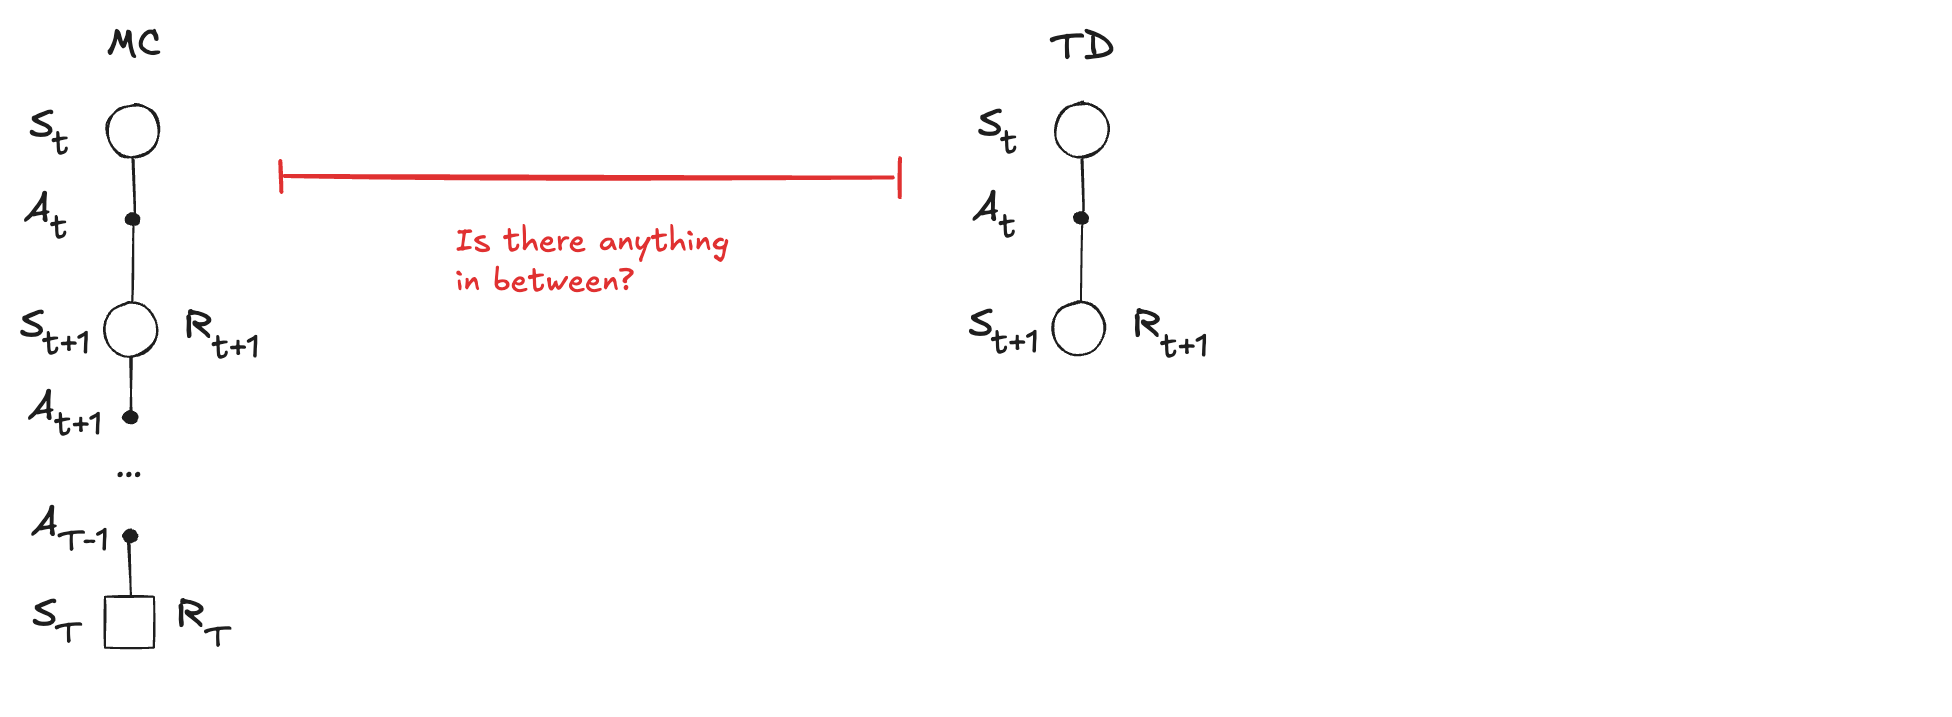

TD bootstraps after one step, but how about after two steps? Three? Four? How many steps should we wait before we estimate the expected return and bootstrap on the value function? There’s a spectrum of algorithms lying in between MC and TD. We can **tune how much bootstrapping**, letting us **balance bias and variance**. We have two extremes (MC and TD methods): MC is an **infinite-step method** (it goes all the way until the end of the episode), TD is a **one-step method** (it interacts with the environment for a single step). We can generalize into an **n-step method**: instead of doing a single step (like TD) or the full episode (like MC), **it uses n-steps to calculate value functions**. This method is called **n-step TD**. We wait n steps before update the state-value function estimation:

$\displaystyle S_{t}, A_{t}, R_{t+1}, S_{t+1}, ... ,R_{t+n}, S_{t+n}$

The number of steps can be less then n if the agent reaches a terminal state before, however it could not be more than n. Once we have these n steps, we can rewrite the equation exploiting the information we collect. Considering the entire episode (MC):

$\displaystyle G_{t:T} = R_{t+1} + \gamma R_{t+2} + ... + \gamma^{T-1}R_T$

$\displaystyle V(S_t) = V(S_t) + \alpha_t [G_{t:T} - V(S_t)]$

Considering just one step (TD):

$\displaystyle G_{t:t+1} = R_{t+1} + \gamma V(S_{t+1})$

$\displaystyle V(S_t) = V(S_t) + \alpha_t [G_{t:t+1} - V(S_t)]$

If we can use n steps:

$\displaystyle G_{t:t+n} = R_{t+1} + \gamma R_{t+2} + ... + \gamma^{n-1} R_{t+n} + \gamma^{n} V(S_{t+n})$

$\displaystyle V(S_t) = V(S_t) + \alpha_t [G_{t:t+n} - V(S_t)]$

where $G_{t:t+n}$ is the **n-step TD target** and $G_{t:t+n} - V(S_t)$ is the **n-step TD error**. When can implement it in Python, notice that it is a hybrid between MC and TD: we need to generate some steps, but instead of going to the end of the episode (like in MC) implementation, we go to  n steps before bootstrapping the estimate: 

In [57]:
def generate_path(pi, env, state, n_steps):

    # list of experiences along the path (part of a trajectory)
    path = []

    done = False
    
    # looping through until the path length is equal to n_steps
    while len(path) < n_steps:

        # use the policy function to pick an action
        action = pi(state);

        # step the environment using that action
        next_state, reward, terminated, truncated, info = env.step(action)
        if(terminated or truncated):
            done = True;

        # append the experience to the path
        experience = (state, action, reward, next_state, done)
        path.append(experience)

        # if we hit a terminal state before n_steps, break and return
        if done: 
            break

        # update the state
        state = next_state

    # return the path
    return np.array(path, object)

Now we can use the path to implement the n-step TD method:

In [58]:
def ntd(pi, env, gamma=1.0, n_steps=3, init_alpha=0.5, min_alpha=0.01, decay_episodes=350, n_episodes=500):    
    # calculate n_step discounts at once 
    discounts = decay_discounts(gamma, n_steps+1);
    
    # calculate all alphas at once
    alphas = decay_alpha(init_alpha, min_alpha, decay_episodes, n_episodes);
      
    # initialize the current estimate of the state-value function
    v = np.zeros(env.observation_space, dtype=float)

    # create a list to save copies of v for offline analysis
    v_track = np.zeros((n_episodes, env.observation_space), dtype=float)
    
    # loop for every episode 
    for e in range(n_episodes):

        # get the initial state
        state, done = env.reset(), False

        # go collecting a series of n-state paths until we hit done
        while not done:

            # generate a path of n-steps (maximum, or less if we hit done)
            path = generate_path(pi, env, state, n_steps)
            
            # calculate the number of steps, could be ‘n_step’ but it could 
            # also be smaller if a terminal state is in the path    
            n = len(path)
        
            # initialize a visits check vector
            visited = np.zeros(env.observation_space, dtype=bool)
        
            # now loop through all experiences in the path
            for t, (state, _, reward, next_state, done) in enumerate(path):                
                
                # calculate the partial return
                partial_return = np.sum(discounts[:n-t] * path[t:, 2])
            
                # update the value function
                ntd_target = partial_return + discounts[n] * v[path[n-1, 3]]
                ntd_error = ntd_target - v[state]
                v[state] = v[state] + alphas[e] * ntd_error
                                           
                state = next_state
                
        # keep track of the episode’s V
        v_track[e] = v
                      
    return v.copy(), v_track

We can apply this method to the Random Walk environment using a 3-step TD:

In [59]:
v_ntd, v_ntd_track = ntd(pi, random_walk, n_steps=3, n_episodes=500)

In [60]:
print(v_ntd)

[0.         0.16004448 0.33393513 0.4931261  0.6482914  0.84844146
 0.        ]


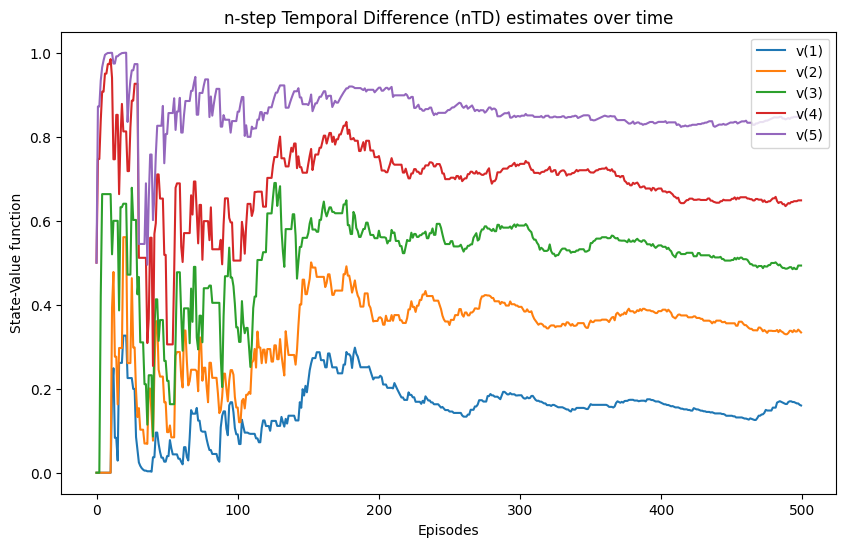

In [61]:
plt.figure(figsize=(10,6))
plt.plot(v_ntd_track[:,1:6])
plt.title('n-step Temporal Difference (nTD) estimates over time')
plt.ylabel('State-Value function')
plt.xlabel('Episodes')
plt.legend(legends)
plt.show()

We can compare with the TD, MC:

In [62]:
rmse_ntd = run_experiment(ntd, 100, random_walk, pi)

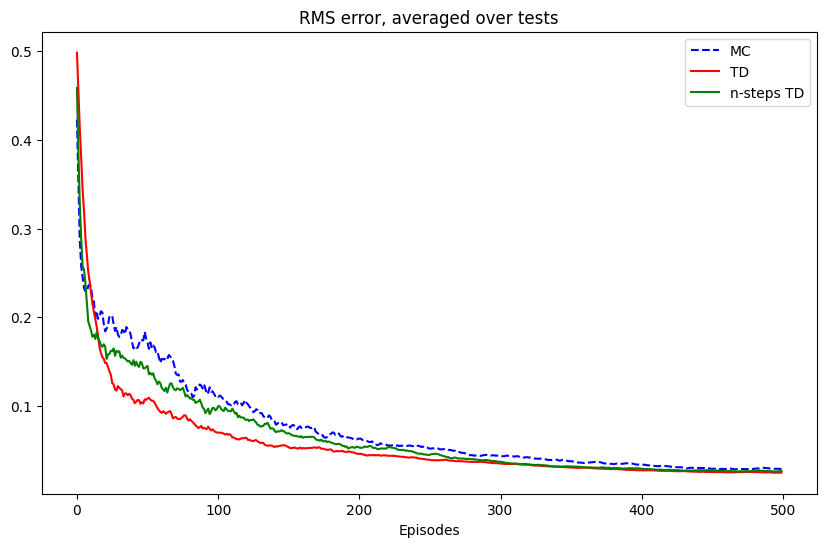

In [63]:
plt.figure(figsize=(10,6))
plt.plot(rmse_mc, color='blue', linestyle='--', label='MC')
plt.plot(rmse_td, color='red', linestyle='-', label='TD')
plt.plot(rmse_ntd, color='green', linestyle='-', label='n-steps TD')
plt.title('RMS error, averaged over tests')
plt.xlabel('Episodes')
plt.legend()
plt.show()

The n-step TD strikes a balance between MC and TD, offering faster convergence than MC but slightly slower than TD. It updates the value estimates using rewards over a few steps and this can **reduces bias (compared to TD)** by considering more actual rewards and **reduces variance (compared to MC)** because it does not wait until the end of the episode. This often leads to **more stable and robust learning**, particularly in environments where rewards are sparse or delayed. However, the **choice of n is crucial**. If n is too small, the algorithm will have high bias and low variance, similar to TD. If n is too large, the algorithm will have low bias and high variance, similar to MC. The optimal value of n depends on the environment and the task.

### Improving estimates of all visited states: TD($\lambda$)

A question emerges, what is a good value for the parameter n? How many steps should the agent wait before updating the value function? How about using a weighted combination of all n-step targets as a single target? The agent could go out, calculates the n-step targets corresponding to the one-, two-, three-, ..., infinite-step target and then **combines all of these targets with an exponentially decaying factor**. This is called **forward-view TD($\lambda$)** method. We can introduce a new parameter **lambda** to control the weighting of the n-step targets in the following way:

- $\lambda$ = 0: TD($\lambda$) should become equivalent to TD learning (for this reason TD is often referred to as TD(0));
- $\lambda$ = 1: TD($\lambda$) should become equivalent to MC;
- 0 < $\lambda$ < 1: TD($\lambda$) should consider multiple steps of future rewards, combining short-term and long-term updates.

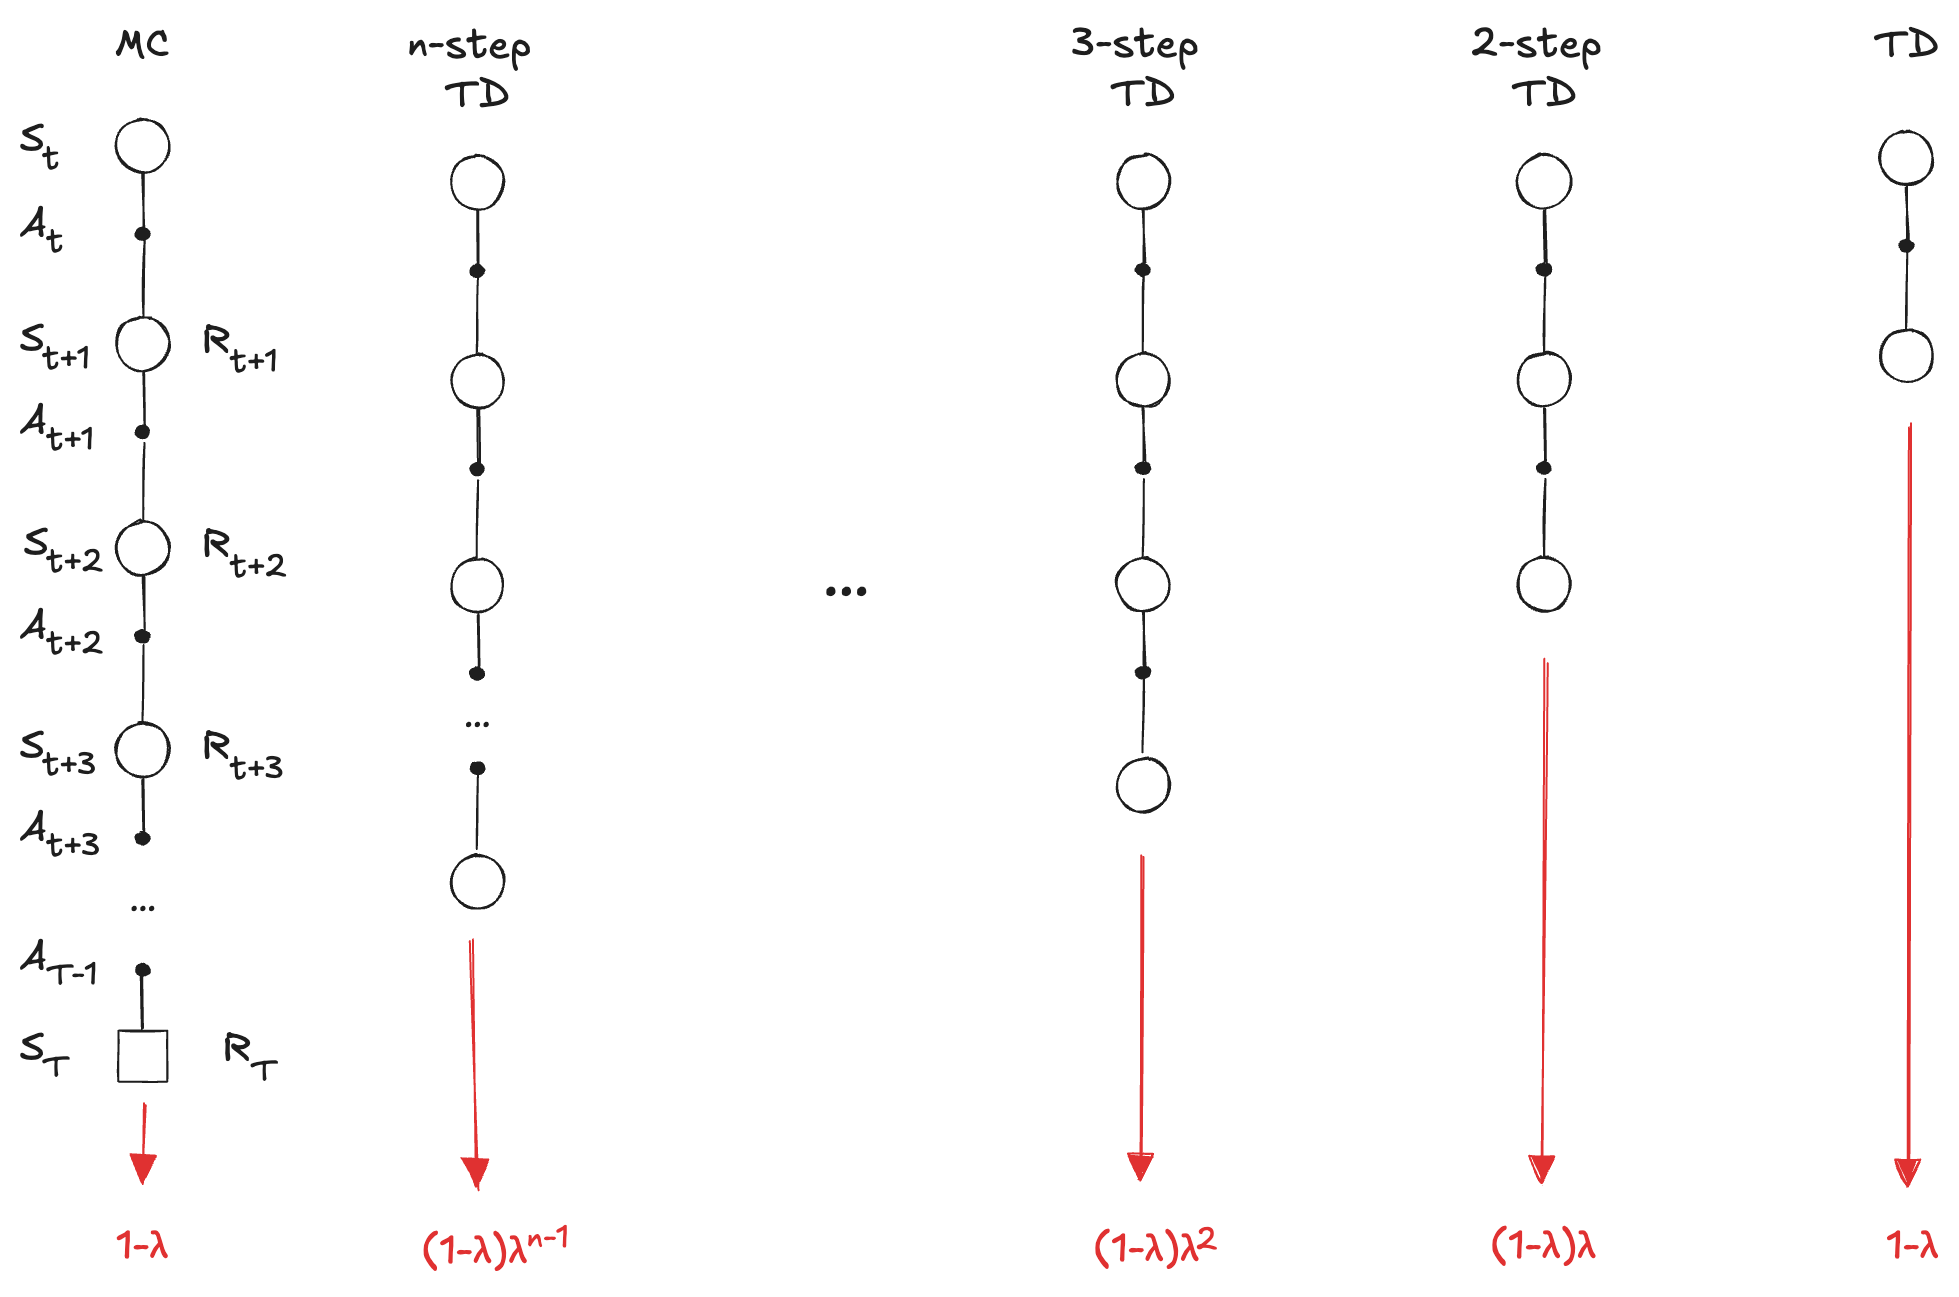

$\displaystyle G_{t:t+1} = R_{t+1} + \gamma V(S_{t+1})$

$\displaystyle G_{t:t+2} = R_{t+1} + \gamma R_{t+2} + \gamma^2 V(S_{t+2})$

...

$\displaystyle G_{t:t+n} = R_{t+1} + \gamma R_{t+2} + ... + \gamma^{n-1} R_{t+n} + \gamma^{n} V(S_{t+n})$

...

$\displaystyle G_{t:T} = R_{t+1} + \gamma R_{t+2} + ... + \gamma^{T-1}R_T$

We can compose all targets using a weighted sum:

$\displaystyle G^\lambda_{t:T} = (1 - \lambda)  \sum\limits_{n=1}^{T-t-1}{\lambda^{n-1}G_{t:t+n}} + \lambda^{T-t-1}G_{t:T}$

In the end, we can evaluate the estimate of the value function using this return:

$\displaystyle V(S_t) = V(S_t) + \alpha_t [G^{\lambda}_{t:T} - V(S_t)]$

where $G^{\lambda}_{t:T}$ is the **TD($\lambda$) target** and $G^{\lambda}_{t:T} - V(S_t)$ is the **TD($\lambda$) error**. 

In this way, forward-view TD(λ) looks ahead to all possible future rewards from the current state and combines them into a single value update, with the contribution of each future reward decaying over time according to the parameter. t provides a way to smoothly interpolate between **short-term learning** (like TD) and **long-term learning** (like MC). However, like MC, it is under **the curse of the time step**, because it can update the state-value function only after reaching a terminal state.

In practice, this idea is typically implemented using a **backward view**, in order to overcome the need to wait until the end of the episode to apply updates.  We exploit the idea of **eligibility trace**. It is a memory that keeps track of how much each state should be credited for future rewards. When a state is visited, its eligibility trace is increased and as time progresses, its trace decays (using a parameter). The fading traces allow the agent to "remember" and update not just the most recent state but a sequence of past states, with a decreasing emphasis the further back in time they were visited:

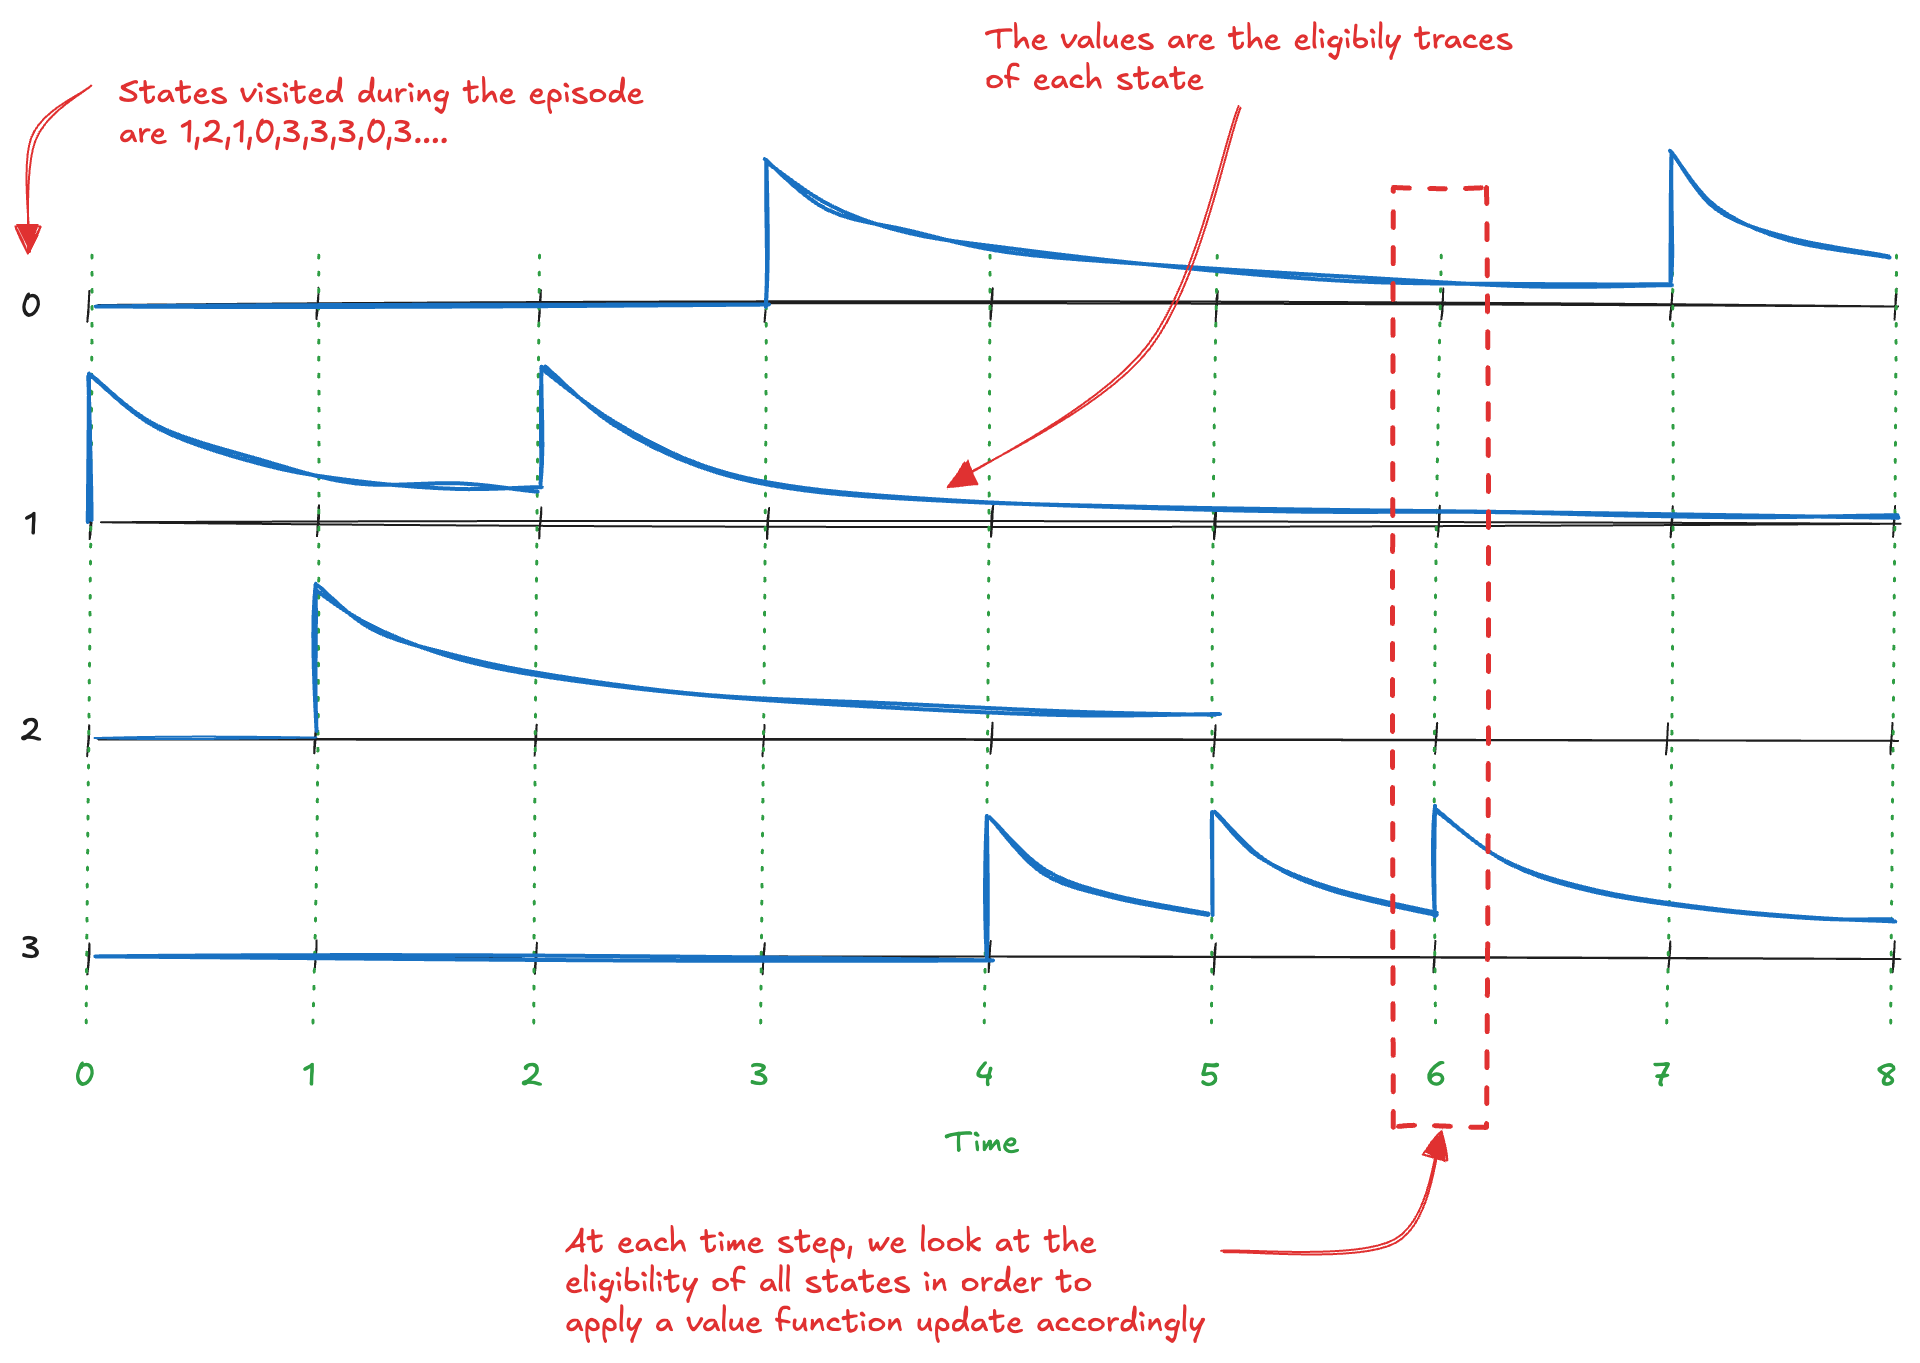

At each time step, the algorithm updates value estimates not only for the current state but for all previously visited states (so withs backward view), weighted by their eligibility traces. The method is called, **backward-view TD($\lambda$)**. At the begging of every new episode, we set the eligibility vector to zero:

$\displaystyle E = 0$

then, we interact with the environment for one step:

$\displaystyle S_{t}, A_{t}, R_{t+1}, S_{t+1}$

we encounter a state and we add one to its trace, in order to mark it as eligible for an update: 

$\displaystyle E(S_t) = E(S_t) + 1$

we then calculate the TD error just as we’ve done so far for TD:

$\displaystyle \delta^{TD}_{t:t+1}(S_t) = R_{t+1} + \gamma V(S_{t+1}) - V(S_t)$

however, we can apply the update to the value function **for all states that are eligible** by multipling it by the eligibility trace vector. In this way, only eligible states will get updated:

$\displaystyle V = V + \alpha_t \delta^{TD}_{t:t+1}(S_t) E$

Notice that we are not updating only $V(S_t)$ but all vector $V$ instead, this is because we’re multiplying by the eligibility vector E, so the eligible states get the corresponding credit.  After each update, the eligibility trace vector is decayed, so that future reinforcing events have less impact on earlier states. By doing this, the most recent states get more significant credit for a reward encountered in a recent transition than those states visited earlier in the episode:

$\displaystyle E = \lambda E$

We can implement the algorithm in Python:

In [ ]:
def td_lambda(pi, env, gamma=1.0, lambda_=0.2, 
              init_alpha=0.5, min_alpha=0.01, 
              decay_episodes=350, n_episodes=500):

    # calculate all alphas at once
    alphas = decay_alpha(init_alpha, min_alpha, decay_episodes, n_episodes);

    # initialize the current estimate of the state-value function
    v = np.zeros(env.observation_space, dtype=float)

    # create a list to save copies of v for offline analysis
    v_track = np.zeros((n_episodes, env.observation_space), dtype=float)
    
    # initialize the eligibility trace vector
    E = np.zeros(env.observation_space, dtype=float)
    
    # loop for every episode
    for e in range(n_episodes):
        
        # set E to zero every new episode
        E.fill(0)
        
        # get the initial state
        state, done = env.reset(), False
        
        # get into the time step loop
        while not done:
            
            # sample the policy pi for the action to take in state
            action = pi(state)
            
            # interact with the environment for one step and get the experience tuple
            next_state, reward, terminated, truncated, info = env.step(action)
            if(terminated or truncated):
                done = True;
            
            # use that experience to calculate the TD error as usual
            td_target = reward + gamma * v[next_state] * (not done)
            td_error = td_target - v[state]
            
            # increment the eligibility of state by 1
            E[state] = E[state] + 1
            
            # apply the error update to all eligible states as indicated by E
            v = v + alphas[e] * td_error * E
            
            # decay E
            E = lambda_ * E
            
            # update the state variable for the next iteration
            state = next_state
            
        v_track[e] = v

    return v, v_track

We can apply this method to the random walk environment:

In [66]:
v_td_lambda, v_td_lambda_track = td_lambda(pi, random_walk, lambda_=0.3, n_episodes=500)

In [67]:
print(v_td_lambda)

[0.         0.19140136 0.39634172 0.5694172  0.72568936 0.87365462
 0.        ]


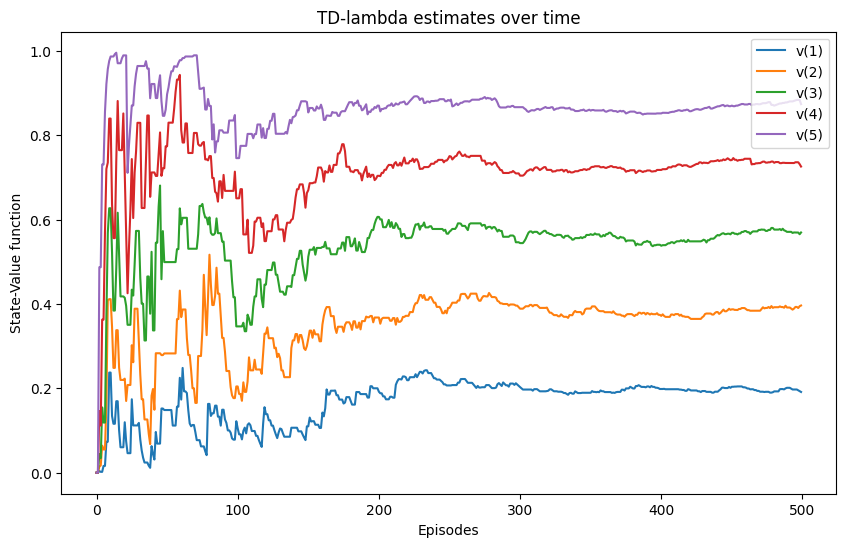

In [69]:
plt.figure(figsize=(10,6))
plt.plot(v_td_lambda_track[:,1:6])
plt.title('TD-lambda estimates over time')
plt.ylabel('State-Value function')
plt.xlabel('Episodes')
plt.legend(legends)
plt.show()

And we can compare with the other methods:

In [70]:
rmse_td_lamda = run_experiment(td_lambda, 100, random_walk, pi)

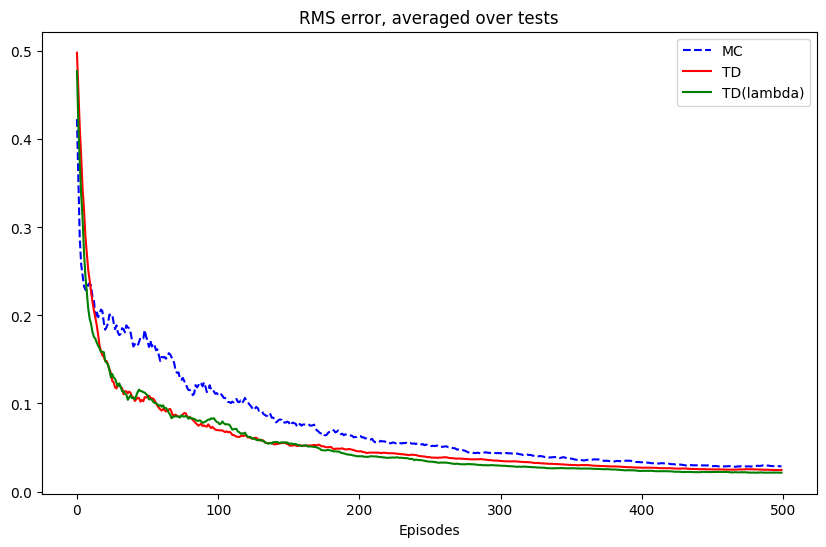

In [72]:
plt.figure(figsize=(10,6))
plt.plot(rmse_mc, color='blue', linestyle='--', label='MC')
plt.plot(rmse_td, color='red', linestyle='-', label='TD')
plt.plot(rmse_td_lamda, color='green', linestyle='-', label='TD(lambda)')
plt.title('RMS error, averaged over tests')
plt.xlabel('Episodes')
plt.legend()
plt.show()

The graph shows that TD($\lambda$) is the most effective method, providing faster convergence and more accurate value function estimates.

## Policy Improvement

Previously, we learned how to evaluate a policy based on how good it is by computing its expected return (cumulative reward) from each state. This is information is captured by the value function. However, this information doesn’t directly make the agent better at any task. Once the value of a policy is known, we can improve the policy by making it greedier. This means adjusting the policy so that in each state, the agent chooses the action that leads to the highest expected value based on the current value function:

$\displaystyle \pi_{k+1}(s) = \underset{a}{\arg \max}\> q_{\pi_k}(s,a)$

This is similar to what we did in the policy-iteration algorithm in Dynamic Programming: we evaluate, we improve, then evaluate the improved policy, then improve on this improved policy, and so on:

$\pi_0 \overset{evaluate}{\longrightarrow }  q_{\pi_0} \overset{improve}{\longrightarrow } \pi_1 \overset{evaluate}{\longrightarrow }  q_{\pi_1} \overset{improve}{\longrightarrow } \pi_2 \overset{evaluate}{\longrightarrow } ... \overset{improve}{\longrightarrow } \pi_* \overset{evaluate}{\longrightarrow }  q_{\pi_*}$

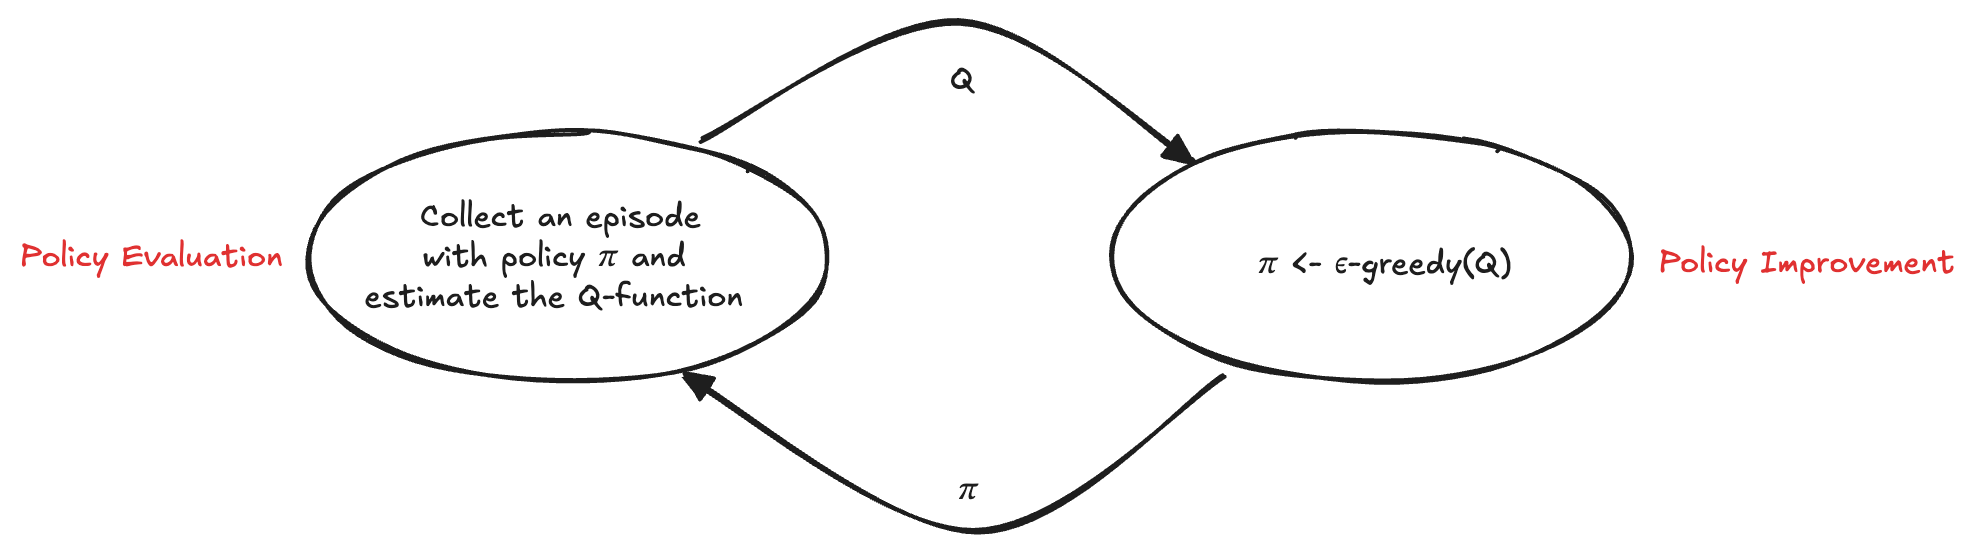

Howerver, in this case **we are not using a model of the environment** to compute the value function, but we estimate the value function based on samples. This ability allows agents to **learn optimal behavior by trial-and-error learning**, starting from arbitrary policies and ending in optimal ones. This pattern is called **generalized policy iteration (GPI)**, and it can help us create an architecture that virtually any reinforcement learning algorithm fits under, including state-of-the-art deep reinforcement learning agents.

### Slippery Walk environment

We use an environment called **Slippery Walk**. This environment is a walk, a single-row grid-world environment, with seven non-terminal states. The particular thing of this environment is that it’s slippery, like the Fronzen Lake: **action effects are stochastic**. If the agent chooses to go left, there is a chance it does, but there is also a chance that it goes right, or that it stays in place.

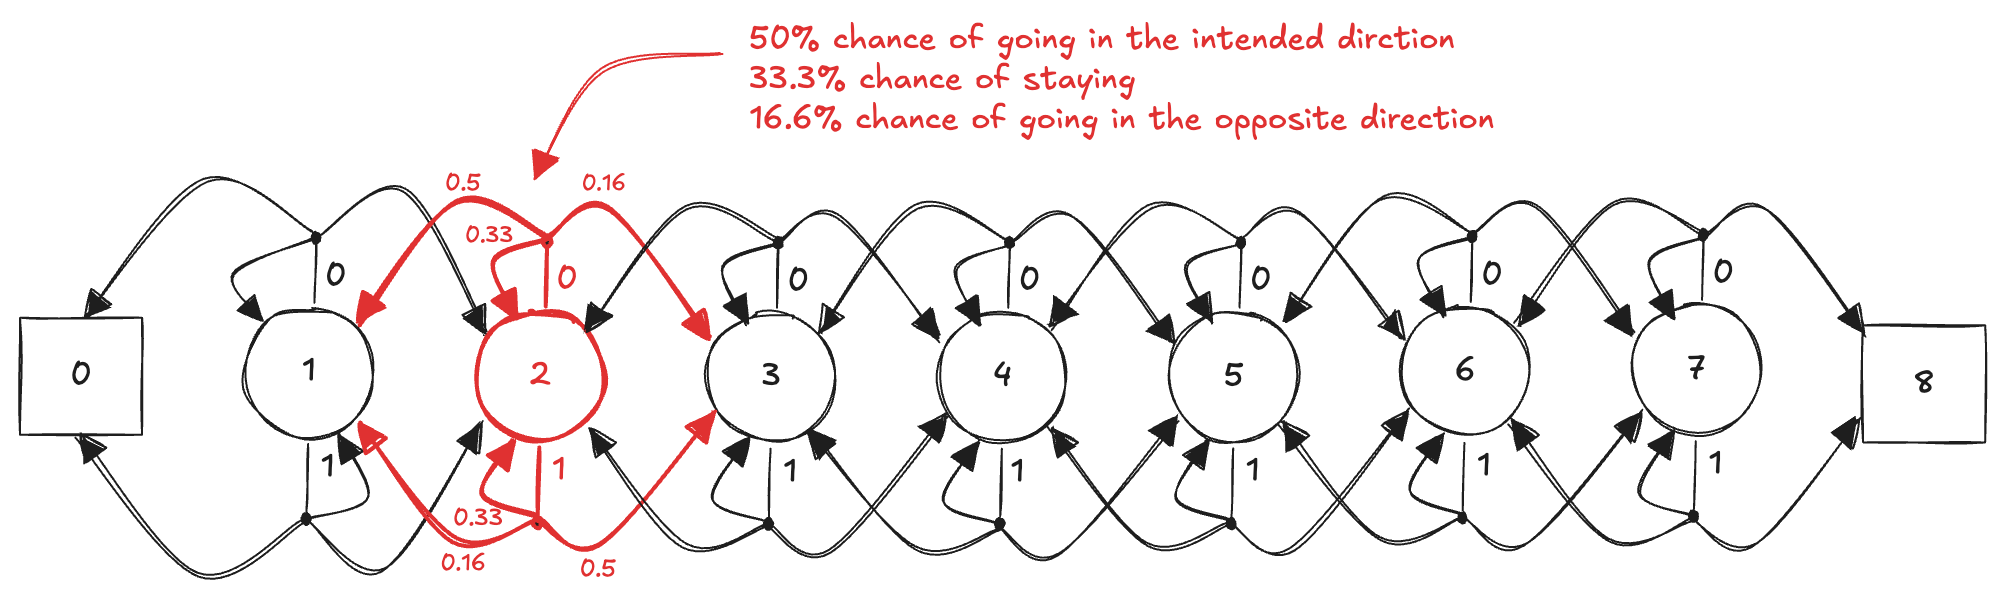

This environment is noisy, but the actions the agent selects make a difference in its performance.

In [1]:
import random
import numpy as np
        
class SlipperyWalk:
    def __init__(self):
        self.reset();

    def reset(self):
        self.observation_space = 9;
        self.action_space = 2;
        self.state = np.random.choice([1,2,3,4,5,6,7]);
        self.terminated = False;
        return self.state;

    def step(self, action):
        if self.terminated: raise ValueError('Episode has terminated');
        if action not in [0, 1]: raise ValueError('Invalid action');
        
        if(action==0): direction = -1;
        if(action==1): direction = 1;
        
        direction_list = [direction, -direction, 0];
        true_direction = random.choices(direction_list, weights=(50, 16, 33), k=1);
        self.state += true_direction[0];
        
        reward = 0
        if self.state < 1: 
            self.terminated = True;
        if self.state > 7: 
            self.terminated = True; 
            reward = 1;
        
        return self.state, reward, self.terminated, 0, 0;

In [2]:
slippery_walk = SlipperyWalk()

The optimal state value function can be calculated using the MDP and applying the Dynamic Programming:

In [3]:
optimal_v = [0., 0.5637, 0.763, 0.8449, 0.8892, 0.922, 0.9515, 0.9806, 0.];

### Improving policies after each episode: Monte Carlo control

The **policy improvement theorem** (as already considered in Dynamic Programming) assures that each new policy is better than (or just as good as) the previous one, so the overall process converges to the optimal policy and optimal value function:

$\displaystyle q_{\pi_k}(s, \pi_{k+1}(s)) = q_{\pi_k}(s, \underset{a}{\arg \max}\> q_{\pi_k}(s,a)) 
 = \underset{a}{\max \>} q_{\pi_k}(s,a)) \geq q_{\pi_k}(s, \pi_k(s)) \geq v_{\pi_k}(s)$

In order to implement this idea, we need to **estimates the action-value function, instead of the state-value function**, in order to know what the best action is to take from a state:

$\displaystyle Q(S_t, A_t) = Q(S_t, A_t) + \alpha [G_{t:T} - Q(S_t, A_t)]$

Then, we need to **explore**, becouse we’re no longer using the MDP for the policy-evaluation. When we estimate from samples, we get values for all of the state-action pairs we visited, but what if part of the best states weren’t visited? Let’s start using **first-visit Monte Carlo** for the policy-evaluation phase and a **decaying epsilon-greedy action-selection strategy** for the policy-improvement phase:

In [4]:
def select_action(state, q, epsilon=0.1):

    # if the random number is greater than epsilon, 
    if np.random.uniform() > epsilon:
        # pick the action with the highest Q value
        action = np.argmax(q[state]);
    else:
        # otherwise, pick a random action
        action = np.random.randint(len(q[0]));

    return action;

In order to decay alpha and epsilon, we use the same decay schedule function used in policy evaluation

In [5]:
def decay_schedule(init_value, min_value, decay_steps, max_steps):

    # calculate the number of the remaining steps after the decay
    rem_steps = max_steps - decay_steps;

    # logspace returns numbers spaced evenly on a log scale
    # base^start is the starting value of the sequence,
    # base^stop is the final value of the sequence
    # num is the number of values to generate
    # base is the base of the log space
    values = np.logspace(start=0, stop=-2, num=decay_steps, base=10);

    # because the values may not end exactly at 0, given it’s the log, 
    # we change them to be between 0 and 1 so that the curve looks smooth and nice.
    values = (values - values.min()) / (values.max() - values.min());

    # linear transformation and get points between init_value and min_value
    values = (init_value - min_value) * values + min_value;

    # repeats the rightmost value rem_step number of times
    values = np.pad(values, (0, rem_steps), 'edge');

    return values;

The generation of a trajectory is slightly different from Part I: the action is no longer given by a fixed policy, but selected by an exploration strategy on the current $Q$ estimates, so we define a separate `generate_trajectory_control`:

In [7]:
def generate_trajectory_control(select_action, q, env, epsilon, max_steps=200):

    # list of experiences (trajectory)
    trajectory = [];

    done = False;
    steps = 0;

    # reset the environment to interact in a new episode
    state = env.reset();

    # looping through until the done flag is set to true
    while not done:
        steps += 1; 

        # there is the difference: use the 'select_action' 
        # function to pick an action
        action = select_action(state, q, epsilon);
            
        # step the environment using that action
        next_state, reward, terminated, truncated, info = env.step(action);
        if(terminated or truncated):
            done = True;

        # append the experience to the trajectory
        experience = (state, action, reward, next_state, done);
        trajectory.append(experience);
        
         # if we hit a terminal state break and return
        if done:
            break;

        # truncate long trajectories 
        if steps >= max_steps:
            break;   
       
        # update the state
        state = next_state;
    
    # return the trajectory
    return np.array(trajectory, object);

Then we can write the Monte Carlo control algorithm, which is similar to one for prediction. The two main differences is that we now estimate the action-value function, and we need to explore (we use an decaying epsilon to control random exploration):

In [8]:
def mc_control(env, gamma=0.99, 
               init_alpha=0.5, min_alpha=0.01, 
               init_epsilon=1.0, min_epsilon=0.1, 
               decay_episodes=1000, n_episodes=3000, 
               max_steps=200):
    
    # calculate all discounts at once. 
    discounts = decay_discounts(gamma, max_steps);
    
    # calculate all alphas at once
    alphas = decay_schedule(init_alpha, min_alpha, decay_episodes, n_episodes);
        
    # calculate all epsilons in advance
    epsilons = decay_schedule(init_epsilon, min_epsilon, decay_episodes, n_episodes);

    # initialize the current estimate of the action-value function
    q = np.zeros((env.observation_space, env.action_space), dtype=float);
    
    # create a list to save copies of v for offline analysis
    v_track = np.zeros((n_episodes, env.observation_space), dtype=float);
    
    # the episode loop    
    for e in range(n_episodes):
        
        # generate a trajectory using the exploratory policy
        trajectory = generate_trajectory_control(select_action, q, env, epsilons[e], max_steps);
        
        # initialize a visits check vector
        visited = np.zeros((env.observation_space, env.action_space), dtype=bool);
        
        # loop through all experiences in the trajectory
        for t, (state, action, reward, _, _) in enumerate(trajectory):
            
            # check if the state-action has already been visited (first-visit MC)
            if visited[state][action]: 
                continue;
            visited[state][action] = True;
            
            # calculate the number of steps from t to T
            n_steps = len(trajectory[t:]);

            # calculate the return
            g = np.sum(discounts[:n_steps] * trajectory[t:, 2]);

            # estimate the value functions
            q[state][action] = q[state][action] + alphas[e] * (g - q[state][action]);

        # extract the state-value function   
        v = np.max(q, axis=1);

        # and the greedy policy
        def pi(s):
            return np.argmax(q[s]);

        # save values for post analysis
        v_track[e] = v;
    
    return q, v, pi, v_track;

Let’s test the algorithm in the Slippery Walk Seven environment: 

In [10]:
q_mc, v_mc, pi_mc, v_track_mc = mc_control(slippery_walk);

We can show the estimates over episodes:

In [11]:
print(v_mc)

[0.         0.52589139 0.75560115 0.82772955 0.89103973 0.92836406
 0.95409788 0.98320711 0.        ]


Of course, the optimal policy learned is obvious in this case, but the algorithm is able to learn it:

In [12]:
def print_policy(pi, env):
    for state in range(env.observation_space):
        action = pi(state)
        action_icon = ' '
        if action == 0: action_icon = 'L'
        if action == 1: action_icon = 'R'
        print('state:', state, '->', 'action:', action_icon)

In [13]:
print_policy(pi_mc, slippery_walk)

state: 0 -> action: L
state: 1 -> action: R
state: 2 -> action: R
state: 3 -> action: R
state: 4 -> action: R
state: 5 -> action: R
state: 6 -> action: R
state: 7 -> action: R
state: 8 -> action: L


We can show the difference between the estimates and the real values:

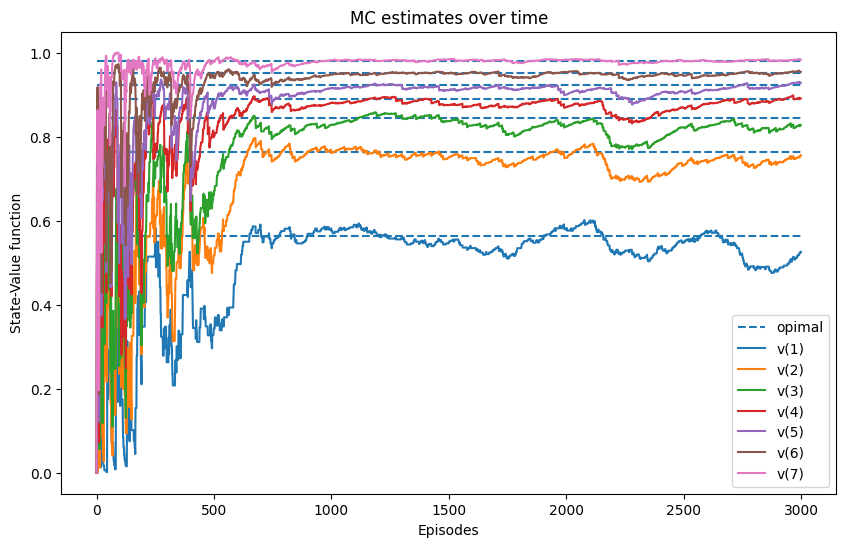

In [14]:
import matplotlib.pyplot as plt

legends = ['opimal', 'v(1)','v(2)','v(3)','v(4)','v(5)', 'v(6)', 'v(7)'];
plt.figure(figsize=(10,6));
plt.hlines(optimal_v[1:8], 0, 3000, linestyle='--');
plt.plot(v_track_mc[:,1:8]);
plt.title('MC estimates over time');
plt.ylabel('State-Value function');
plt.xlabel('Episodes');
plt.legend(legends);
plt.show();

Notice how **the estimates of MC have high variance**. We can use a brute-force approach to get the average return of the policy and its success probability.

In [12]:
def evaluate(env, pi, n_episodes=1000, max_steps=200):
    success = 0;
    results = [];
    for _ in range(n_episodes):
        done = False;
        steps = 0;
        state = env.reset();
        results.append(0.0);
        while not done and steps < max_steps:
            state, reward, terminated, truncated, info = env.step(pi(state));
            if(terminated or truncated):
                done = True;
            results[-1] += reward;
            steps += 1;
        if(done and reward==1):
            success += 1;
    return (success/n_episodes)*100, np.mean(results);

In [13]:
probability_success_mc, mean_return_mc = evaluate(slippery_walk, pi_mc);

print("Reaches goal ", probability_success_mc, "%");
print("Obtains an average undiscounted return of ", mean_return_mc);

Reaches goal  93.30000000000001 %
Obtains an average undiscounted return of  0.933


### Improving policies after each step: SARSA

Monte Carlo method is an **offline** method in an episode-to-episode sense: we must wait until a terminal state before we can make any improvements to the value function estimate. So, it is straightforward to apply **temporal-difference prediction** for the policy-evaluation phase in order to remove this limitation. The algorithm is called **SARSA agent** ([Rummery & Niranjan, "Online Q-Learning using Connectionist Systems" (1994)](./papers/1994%20-%20Online%20Q-Learning%20using%20Connectionist%20Systems.pdf):

$\displaystyle G_{t:t+1} = R_{t+1} + \gamma Q(S_{t+1}, A_{t+1})$

We can substitute in the formula for the evaluation of the action-value function:

$\displaystyle Q(S_t, A_t) = Q(S_t, A_t) + \alpha_t [G_{t:t+1} - Q(S_t, A_t)]$

where $G_{t:t+1}$ is the **SARSA target** and $G_{t:t+1} - Q(S_t, A_t)$ is the **SARSA error**.

We can implement it in Python:

In [15]:
def sarsa(env, gamma=0.99, 
          init_alpha=0.5, min_alpha=0.01, 
          init_epsilon=1.0, min_epsilon=0.1, 
          decay_episodes=1000, n_episodes=3000):
    
    # calculate the learning rate schedule for all episodes    
    alphas = decay_schedule(init_alpha, min_alpha, decay_episodes, n_episodes);

    # calculate epsilon for all episodes   
    epsilons = decay_schedule(init_epsilon, min_epsilon, decay_episodes, n_episodes);

    # initialize the current estimate of the action-value function
    q = np.zeros((env.observation_space, env.action_space), dtype=float);
    
    # create a list to save copies of v for offline analysis
    v_track = np.zeros((n_episodes, env.observation_space), dtype=float);

    # the episode loop    
    for e in range(n_episodes):
        
        # we start episode by resetting the environment and the done flag
        state, done = env.reset(), False;
        
        # select the action (perhaps exploratory) for the initial state
        action = select_action(state, q, epsilons[e]);
        
        # repeat until we hit a terminal state
        while not done:
            
            # step the environment using that action
            next_state, reward, terminated, truncated, info = env.step(action);
            if(terminated or truncated):
                done = True;
            
            # obtain the action for the next step
            next_action = select_action(next_state, q, epsilons[e]);
            
            # calculate the target using that next state-action pair
            sarsa_target = reward + gamma * q[next_state][next_action]
            
            # calculate the error                                   
            sarsa_error = sarsa_target - q[state][action];
            
            # update the action-value function
            q[state][action] = q[state][action] + alphas[e] * sarsa_error;
                        
            # update state and action for the next step
            state, action = next_state, next_action;
            
        # extract the state-value function   
        v = np.max(q, axis=1);

        # and the greedy policy
        def pi(s):
            return np.argmax(q[s]);

        # save values for post analysis   
        v_track[e] = v;
    
    return q, v, pi, v_track;

Now we can run SARSA against the  Slippery Walk environment:

In [16]:
q_sarsa, v_sarsa, pi_sarsa, v_track_sarsa = sarsa(slippery_walk);

In [17]:
print(v_sarsa);

[0.         0.52063677 0.71702406 0.81401339 0.86784435 0.90884011
 0.94304096 0.97815134 0.        ]


We can show the estimates over episodes and the difference between the estimates and the real values:

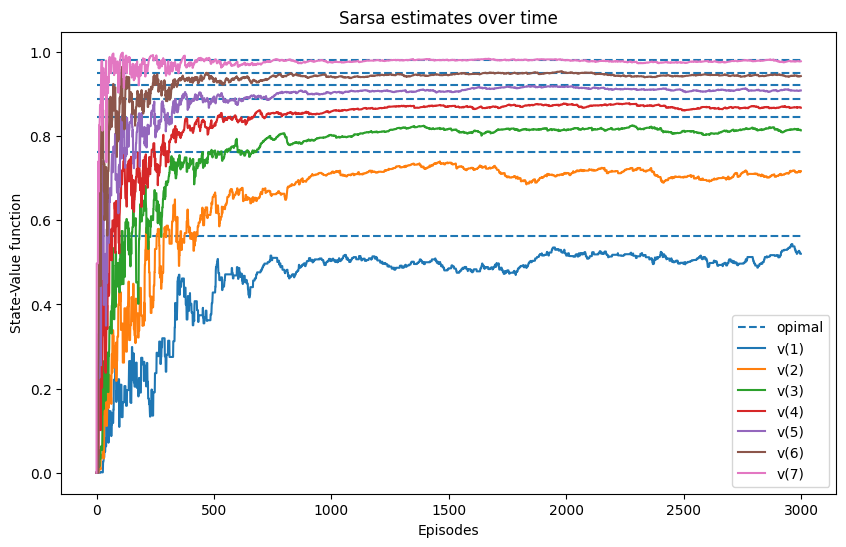

In [18]:
plt.figure(figsize=(10,6));
plt.hlines(optimal_v[1:8], 0, 3000, linestyle='--');
plt.plot(v_track_sarsa[:,1:8]);
plt.title('Sarsa estimates over time');
plt.ylabel('State-Value function');
plt.xlabel('Episodes');
plt.legend(legends);
plt.show();

We can see how SARSA has less variance than MC, but it slower to converge, particularly for low-value states. Again, we can use the brute-force approach to get the average return of the policy and its success probability:

In [18]:
probability_success_sarsa, mean_return_sarsa = evaluate(slippery_walk, pi_sarsa);

print("Reaches goal ", probability_success_sarsa, "%");
print("Obtains an average undiscounted return of ", mean_return_sarsa);

Reaches goal  93.30000000000001 %
Obtains an average undiscounted return of  0.933


Monte Carlo and SARSA must meet some requirements to guarantee convergence to the optimal policy: (a) **all state-action pairs must be explored infinitely often** and (b) **the policy must converge on a greedy policy**. In practice, this means that an the epsilon-greedy exploration strategy must slowly decay epsilon towards zero. If it goes down too quickly, the first condition may not be met; if it decays too slowly, well, it takes longer to converge.

### Decoupling behavior from learning: Q-Learning

The SARSA algorithm is a sort of "learning on the job", the agent learns the value of the policy it is currently following, which means it **evaluates and improves the same policy that it is using to make decisions**. The agent explores and exploits the environment according to the same policy it is updating. This type of learning is called **on-policy learning**. It is excellent, we learn from our own mistakes. But we learn from our own current mistakes only. What if we want to learn from our own previous mistakes? What if we want to learn from the mistakes of others? The **Off-policy learning** approach is sort of "learning from others": the agent **learns the value of an optimal policy, but it follows a different behavior policy to explore** the environment. In other words, it separates the policy it uses to explore (**behavior policy**) from the policy it is trying to optimize (**target policy**). The most used off-policy algorithm is called **Q-Learning** ([Watkins, "Learning from Delayed Rewards" (1989)](./papers/1989%20-%20Learning%20from%20Delayed%20Rewards.pdf). The difference between SARSA and Q-learning is the action used to calculate the target. SARSA uses the action taken in the next state, Q-learning uses the action with the maximum estimated value in the next state, despite the action taken:

$\displaystyle G_{t:t+1} = R_{t+1} + \gamma \underset{a}{\text{ max }} Q(S_{t+1}, a)$

We can substitute in the formula for the evaluation of the action-value function:

$\displaystyle Q(S_t, A_t) = Q(S_t, A_t) + \alpha_t [G_{t:t+1} - Q(S_t, A_t)]$

where $G_{t:t+1}$ is the **Q-learning target** and $G_{t:t+1} - Q(S_t, A_t)$ is the **Q-learning error**.

Q-Learning algorithm will evaluate all possible state-actions pairs and choose that pair which will generate maximum expected rewards (which is the value of the state). Off-policy methods can converge faster because they are not restricted by the exploration-exploitation balance of the behavior policy. We can implement it in Python:

In [19]:
def q_learning(env, gamma=0.99, 
               init_alpha=0.5, min_alpha=0.01, 
               init_epsilon=1.0, min_epsilon=0.1, 
               decay_episodes=1000, n_episodes=3000):
    
    # calculate the learning rate schedule for all episodes    
    alphas = decay_schedule(init_alpha, min_alpha, decay_episodes, n_episodes);

    # calculate epsilon for all episodes   
    epsilons = decay_schedule(init_epsilon, min_epsilon, decay_episodes, n_episodes);

    # initialize the current estimate of the action-value function
    q = np.zeros((env.observation_space, env.action_space), dtype=float);
    
    # create a list to save copies of v for offline analysis
    v_track = np.zeros((n_episodes, env.observation_space), dtype=float);
    
    # the episode loop    
    for e in range(n_episodes):

        # we start episode by resetting the environment and the done flag
        state, done = env.reset(), False;

        # repeat until we hit a terminal state
        while not done:

            # select the action
            action = select_action(state, q, epsilons[e]);

            # step the environment using that action
            next_state, reward, terminated, truncated, info = env.step(action);
            if(terminated or truncated):
                done = True;
            
            # calculate the target: here is Q-learning!
            q_learning_target = reward + gamma * q[next_state].max();
            
            # calculate the error 
            q_learning_error = q_learning_target - q[state][action];

            # update the action-value function
            q[state][action] = q[state][action] + alphas[e] * q_learning_error;

            # update state for the next step
            state = next_state;

        # extract the state-value function   
        v = np.max(q, axis=1);

        # and the greedy policy
        def pi(s):
            return np.argmax(q[s]);
        
        # save values for post analysis   
        v_track[e] = v;

    return q, v, pi, v_track;

Now we can run Q-Learning against the  Slippery Walk environment:

In [20]:
q_ql, v_ql, pi_ql, v_track_ql = q_learning(slippery_walk);

In [21]:
print(v_ql)

[0.         0.57510604 0.77902023 0.8516414  0.89468035 0.92487707
 0.95390326 0.9799436  0.        ]


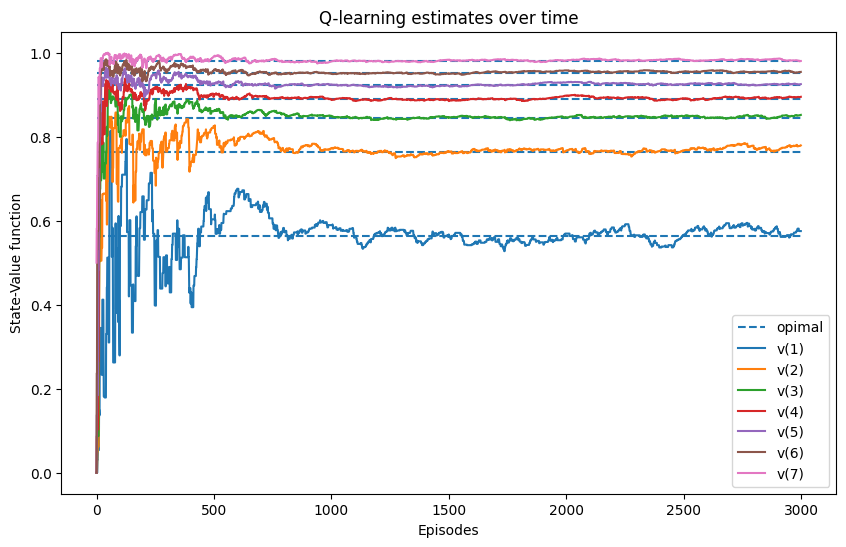

In [22]:
plt.figure(figsize=(10,6));
plt.hlines(optimal_v[1:8], 0, 3000, linestyle='--');
plt.plot(v_track_ql[:,1:8]);
plt.title('Q-learning estimates over time');
plt.ylabel('State-Value function');
plt.xlabel('Episodes');
plt.legend(legends);
plt.show();

See how much **faster** the estimates track the true values. But, also, notice how the estimates are often higher and **jump around** somewhat aggressively.

In [23]:
probability_success_ql, mean_return_ql = evaluate(slippery_walk, pi_ql);

print("Reaches goal ", probability_success_ql, "%");
print("Obtains an average undiscounted return of ", mean_return_ql);

Reaches goal  92.60000000000001 %
Obtains an average undiscounted return of  0.926


Notice that for off-policy algorithms the only requirement that holds of the two for convergence is the first one (all state-action pairs must be explored infinitely often). The second one (the policy must converge on a greedy policy) is no longer a requirement, because the learned policy is different than the one used to sampling actions.

### Solving the maximization bias: Double Q-Learning

Q-learning often **overestimates the value function**. On every step, we take the **maximum over the estimates** of the action-value function of the next state, but what we need is an **estimate of the maximum** of the action-value function of the next state. We are using the **maximum over estimates as an estimate of the maximum**. Consider the Q-learning update rule:

$\displaystyle G_{t:t+1} = R_{t+1} + \gamma \underset{a}{\text{ max }} Q(S_{t+1}, a)$

$\displaystyle Q(S_t, A_t) = Q(S_t, A_t) + \alpha_t [G_{t:t+1} - Q(S_t, A_t)]$

Here, the maximum over the estimates is used to select the action with the maximum estimated future reward. However, if the estimates of are noisy or imprecise (which is often the case early in training), the **maximization tends to select actions with overestimated values**. This leads to a systematic bias towards overestimating the value of the chosen actions. This is a problem known as **maximization bias**. Imagine an action-value function whose actual values are all zeros, but the estimates have errors (0.11, 0.65, –0.44, –0.26, and so on). We know the actual maximum is zero, but the maximum over the estimates is 0.65. One way of dealing with this is a technique called **double Q-learning** [Hasselt, Hado. "Double Q-learning." Advances in neural information processing systems NIPS (2010)](./papers/2010%20-%20Double%20Q-learning.pdf). In this approach, two separate action-value estimates are maintained, and the update rule is modified to reduce bias. One action-value function is used to select the action with the maximum value. The other action-value function is used to evaluate the value of that action, thus **breaking the dependence between action selection and value estimation**. This approach helps to reduce the overestimation problem by decoupling the action selection from the max operator, leading to more stable and accurate learning. The issue, though, is now we are splitting the experience between two separate functions and this somewhat **slows down training**. Other Methods, like **Weighted Q-learning** and **softmax selection** can also mitigate the bias, though they are less common compared to Double Q-learning. We can implement the idea in Python:

In [23]:
def double_q_learning(env, gamma=0.99, 
                      init_alpha=0.5, min_alpha=0.01, 
                      init_epsilon=1.0, min_epsilon=0.1, 
                      decay_episodes=1000, n_episodes=3000):
    
    # calculate the learning rate schedule for all episodes    
    alphas = decay_schedule(init_alpha, min_alpha, decay_episodes, n_episodes);

    # calculate epsilon for all episodes   
    epsilons = decay_schedule(init_epsilon, min_epsilon, decay_episodes, n_episodes);

    # initialize the two action-value functions
    q1 = np.zeros((env.observation_space, env.action_space), dtype=float);
    q2 = np.zeros((env.observation_space, env.action_space), dtype=float);

    # create a list to save copies of v for offline analysis
    v_track = np.zeros((n_episodes, env.observation_space), dtype=float);
    
    # the episode loop    
    for e in range(n_episodes):

        # we start episode by resetting the environment and the done flag
        state, done = env.reset(), False;

        # repeat until we hit a terminal state
        while not done:
            
            # we use the mean of our two action-value functions to select action 
            action = select_action(state, (q1 + q2)/2., epsilons[e]);

            # step the environment using that action
            next_state, reward, terminated, truncated, info = env.step(action);
            if(terminated or truncated):
                done = True;
            
            # flip a coin to determine an update to q1 or q2
            if np.random.randint(2):

                # use the action q1 thinks is best...
                argmax_q1 = np.argmax(q1[next_state]);
                
                # ...but get the value from q2 to calculate the target
                dq_learning_target = reward + gamma * q2[next_state][argmax_q1];

                # calculate the error 
                dq_learning_error = dq_learning_target - q1[state][action];
                
                # update q1
                q1[state][action] = q1[state][action] + alphas[e] * dq_learning_error;

            else:
                
                # use the action q2 thinks is best...
                argmax_q2 = np.argmax(q2[next_state]);
                
                # ...but get the value from q1 to calculate the target
                dq_learning_target = reward + gamma * q1[next_state][argmax_q2];
                dq_learning_error = dq_learning_target - q2[state][action];
                
                # update q2
                q2[state][action] = q2[state][action] + alphas[e] * dq_learning_error;
            
            # update state
            state = next_state;
        
        # extract the value functions
        q = (q1 + q2)/2.;
        v = np.max(q, axis=1);

        # and the greedy policy
        def pi(s):
            return np.argmax(q[s]);
        
        # save values for post analysis
        v_track[e] = v
    
    return q, v, pi, v_track;

Now we can run Double Q-Learning against the  Slippery Walk environment:

In [24]:
q_dql, v_dql, pi_dql, v_track_dql = double_q_learning(slippery_walk);

In [26]:
print(v_dql)

[0.         0.58634552 0.7786524  0.85104747 0.89197395 0.92670831
 0.95368596 0.98076035 0.        ]


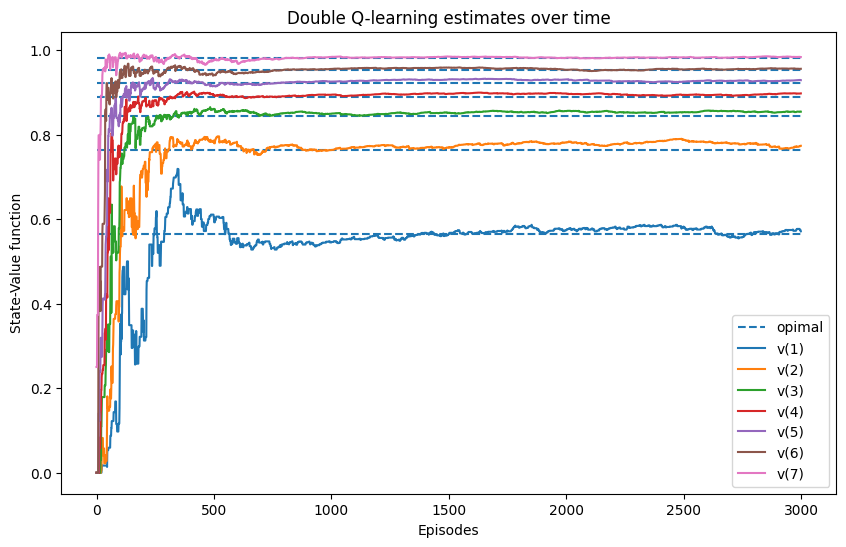

In [25]:
plt.figure(figsize=(10,6));
plt.hlines(optimal_v[1:8], 0, 3000, linestyle='--');
plt.plot(v_track_dql[:,1:8]);
plt.title('Double Q-learning estimates over time');
plt.ylabel('State-Value function');
plt.xlabel('Episodes');
plt.legend(legends);
plt.show();

It is **slightly slower** than Q-learning to get the estimates to track the optimal values, but it does so in a **much more stable manner**. There’s still a bit of over-estimation, but it’s controlled.

### Using multi-step estimates: SARSA(lambda)

A straightforward improvement to the original SARSA agent is **to use the lambda-return  instead of using a one-step bootstrapping target**. For adapting the eligibility trace to the estimation of action-value function, instead of using a vector for tracking visited states, we use an **eligibility matrix** for tracking visited state-action pairs. When the agent tries a state-action pair, the trace for this pair is incremented by one. Now, imagine there is a loop in the environment, and the agent tries the same state-action pair several times. Should we make this state-action pair **"more" responsible** for rewards obtained in the future, or should we make it **just responsible**? The first type of eligibility trace is called **accumulating trace** (and allows trace values higher than one), the other one is the **replacing trace** (it clips eligibility traces to a maximum value of one). The following figure shows the two strategy applied to the Slippery Walk environment:

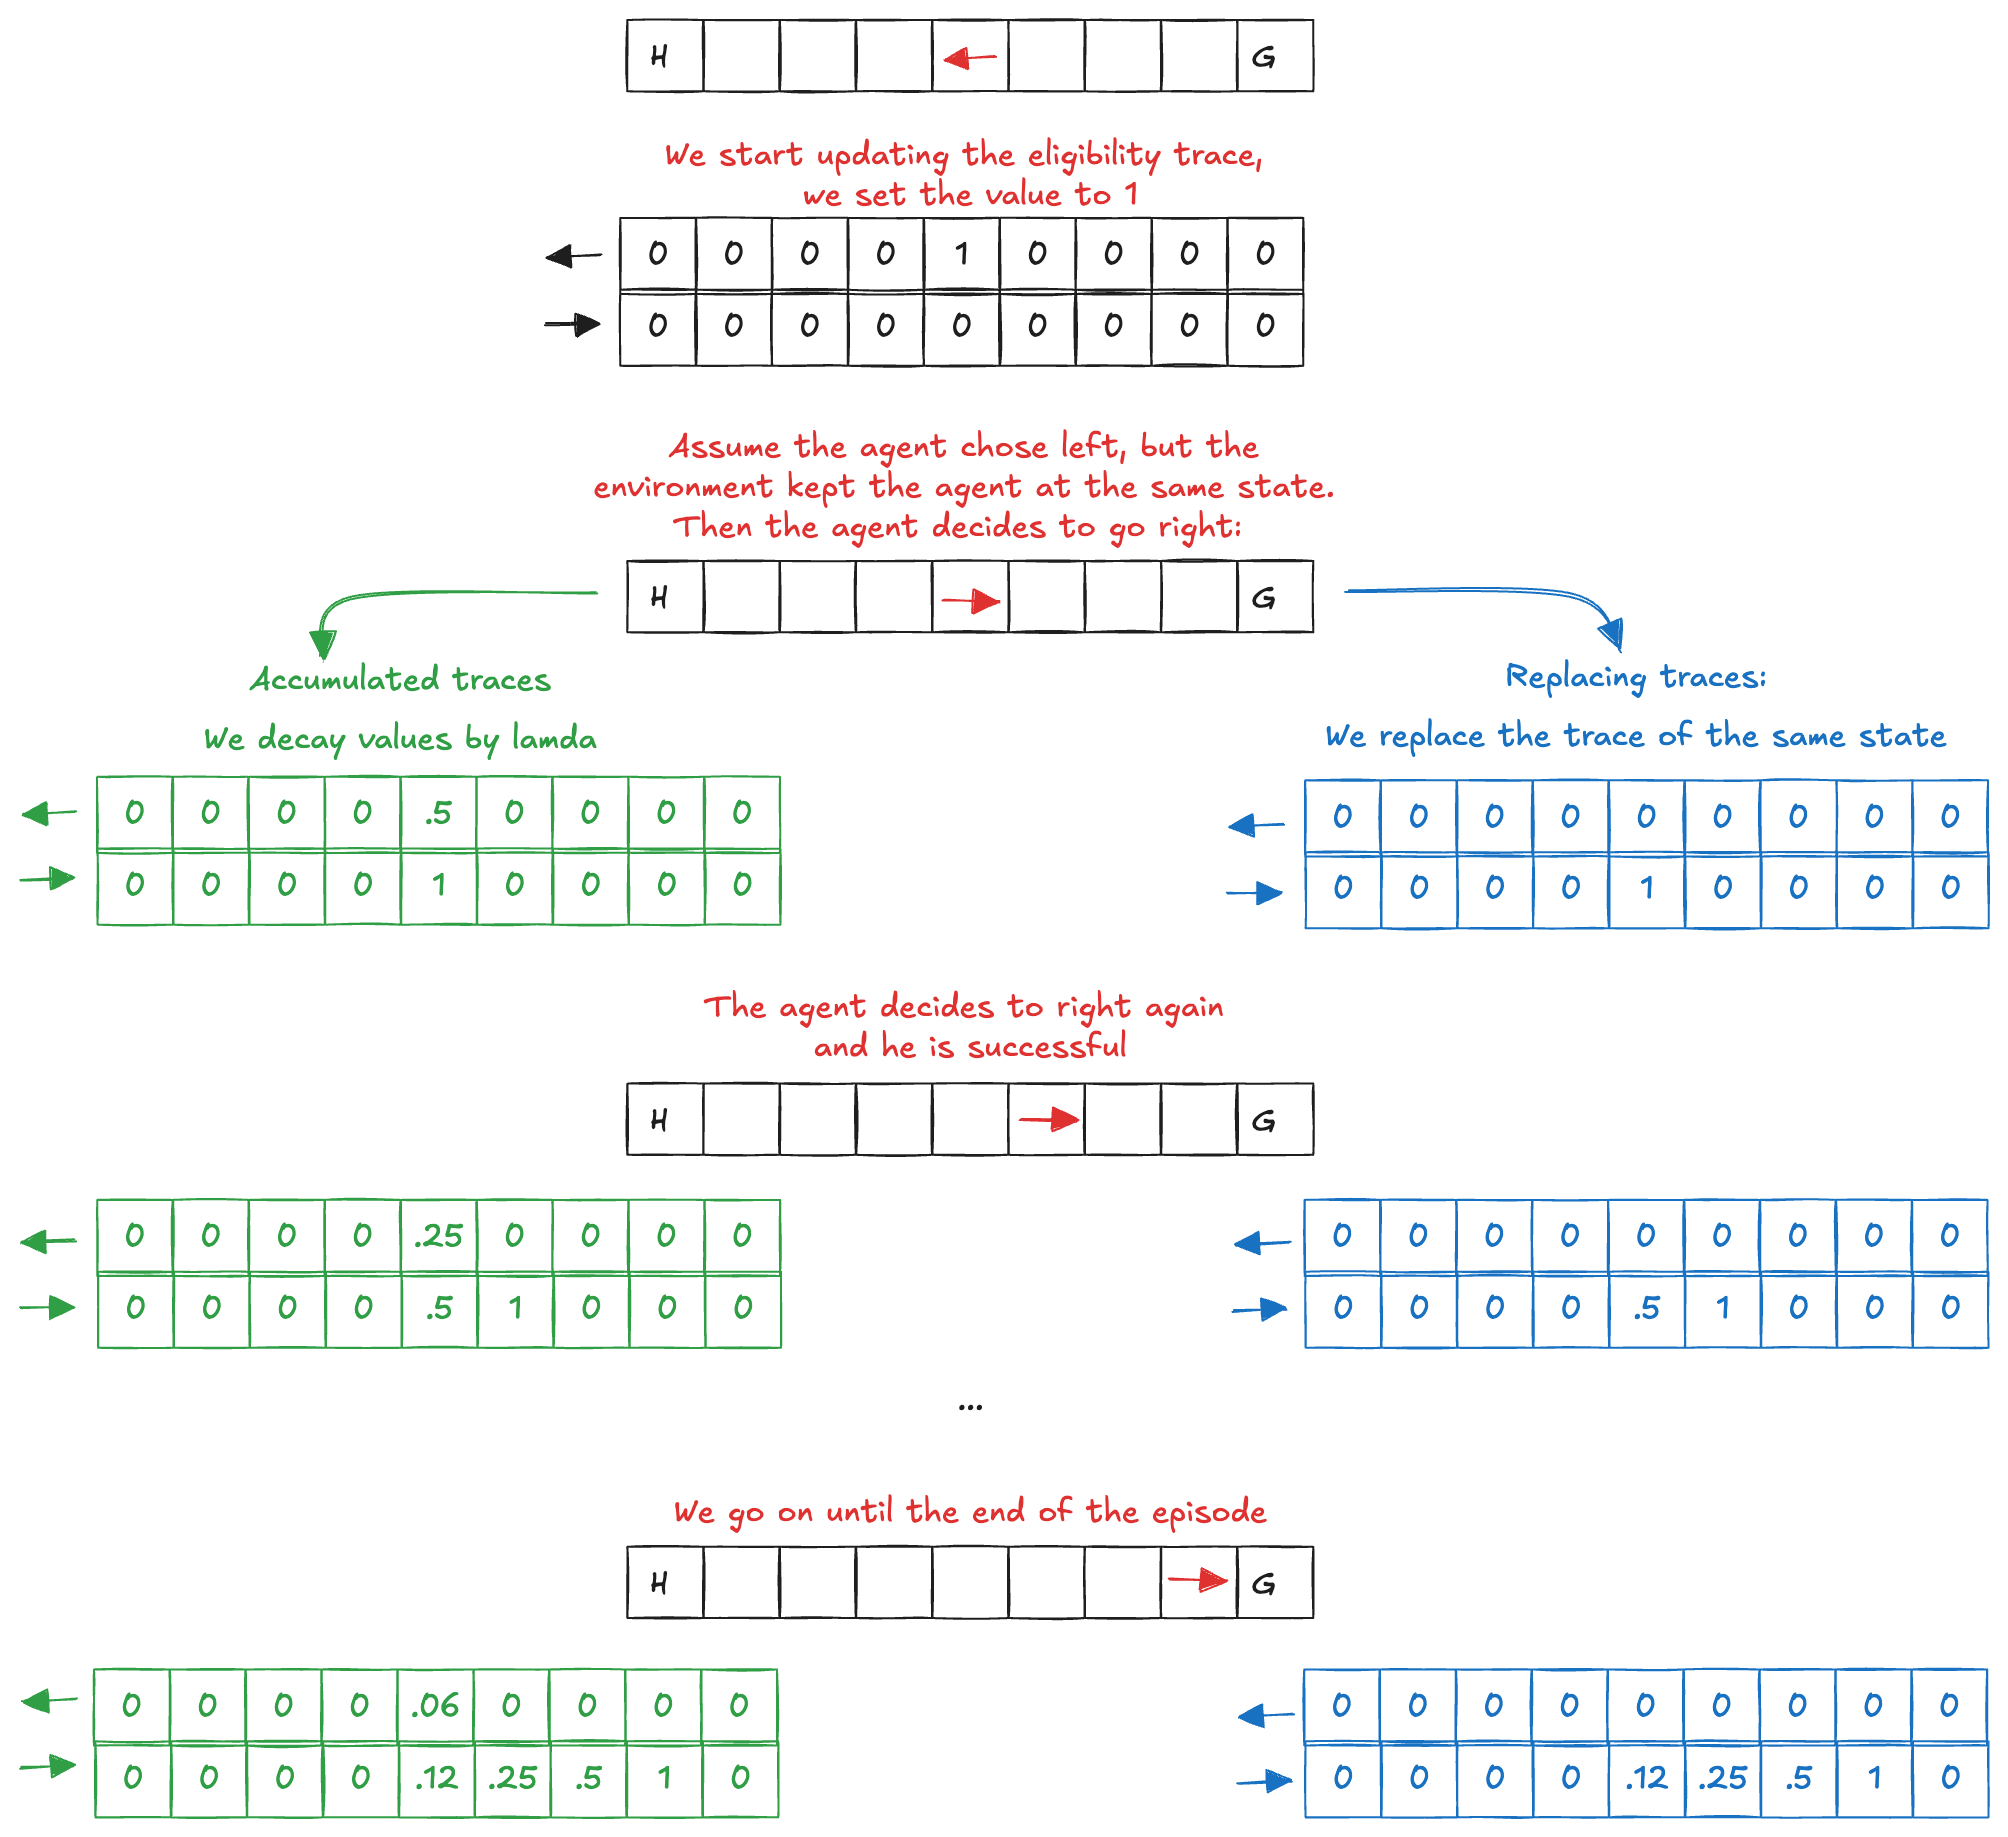

Accumulating traces can "exaggerate" when confronted with frequency, while replacing traces moderate the blame assigned to frequent events. This moderation can help the more recent, but rare events surface and be taken into account. We can implement this variation of SARSA in Python:

In [ ]:
def sarsa_lambda(env, gamma=0.99, 
                 init_alpha=0.5, min_alpha=0.01, 
                 init_epsilon=1.0, min_epsilon=0.1, 
                 lambda_=0.5, replacing_traces=True,
                 decay_episodes=1000, n_episodes=3000):
    
    # calculate the learning rate schedule for all episodes    
    alphas = decay_schedule(init_alpha, min_alpha, decay_episodes, n_episodes);

    # calculate epsilon for all episodes   
    epsilons = decay_schedule(init_epsilon, min_epsilon, decay_episodes, n_episodes);

    # initialize the current estimate of the action-value function
    q = np.zeros((env.observation_space, env.action_space), dtype=float);

    # eligibility traces
    E = np.zeros((env.observation_space, env.action_space), dtype=float);

    # create a list to save copies of v for offline analysis
    v_track = np.zeros((n_episodes, env.observation_space), dtype=float);

    # the episode loop
    for e in range(n_episodes):
      
        # every new episode, set the eligibility of every state to zero
        E.fill(0);

        # we start episode by resetting the environment and the done flag
        state, done = env.reset(), False;

        # select the action (perhaps exploratory) for the initial state
        action = select_action(state, q, epsilons[e]);
        
        # repeat until we hit a terminal state
        while not done:
            
            # step the environment using that action
            next_state, reward, terminated, truncated, info = env.step(action);
            if(terminated or truncated):
                done = True;
            
            # obtain the action for the next step
            next_action = select_action(next_state, q, epsilons[e]);

            # calculate the target using that next state-action pair
            sarsa_lambda_target = reward + gamma * q[next_state][next_action];
            
            # calculate the error  
            sarsa_lambda_error = sarsa_lambda_target - q[state][action];
            
            # increment the state-action pair trace, 
            # and clip it to 1 if it’s a replacing trace
            if replacing_traces: 
                E[state].fill(0);
            E[state][action] = E[state][action] + 1;
            if replacing_traces: 
                E.clip(0, 1, out=E);
            
            # apply the error to all eligible state-action pairs at once
            # even though we're using the entire q-table, E will be mostly 0, 
            # and greater than zero for eligible pairs
            q = q + alphas[e] * sarsa_lambda_error * E;
            
            # decay the eligibility matrix
            E = lambda_ * E;
            
            # update state and action for the next step
            state, action = next_state, next_action;
        
        # extract the state-value function   
        v = np.max(q, axis=1);

        # and the greedy policy
        def pi(s):
            return np.argmax(q[s]);

        # save values for post analysis   
        v_track[e] = v;
    
    return q, v, pi, v_track;

We can apply the algorithm to the same SWS environment:

In [29]:
q_sarsa_lambda, v_sarsa_lambda, pi_sarsa_lambda, v_track_sarsa_lambda = sarsa_lambda(slippery_walk);

In [30]:
print(v_sarsa_lambda);

[0.         0.49629043 0.713757   0.81630604 0.88155212 0.9197797
 0.94863288 0.9778924  0.        ]


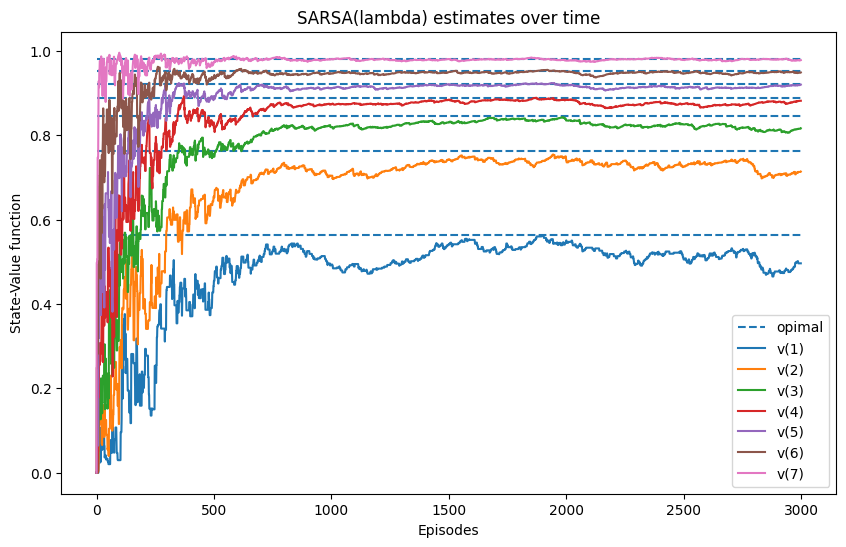

In [31]:
plt.figure(figsize=(10,6));
plt.hlines(optimal_v[1:8], 0, 3000, linestyle='--');
plt.plot(v_track_sarsa_lambda[:,1:8]);
plt.title('SARSA(lambda) estimates over time');
plt.ylabel('State-Value function');
plt.xlabel('Episodes');
plt.legend(legends);
plt.show();

By updating past state-action pairs, Sarsa(almbda) learns faster in environments where rewards are delayed. It is better at distributing the reward credit over multiple past actions, making it effective in tasks with longer time dependencies. However it requires maintaining eligibility traces and tuning the lambda parameter, making it more computationally demanding than regular Sarsa. Moreover, the choice of lambda can significantly affect performance, and improper tuning might degrade learning performance.

### Using multi-step estimates and decoupling behaviour from learning: Q(lambda)

We can extend also the Q-learning in order to use the lambda-return for evaluation. We need to replace the target (that uses the max over the action in the next state) with a lambda-return. Moreover, since Q-learning is an off-policy method, we must use the eligibility trace with care. We’re learning about the greedy policy, but following an exploratory policy. So, if an action we’ll take on the next state is a greedy action (so if the exploratory policy follows the same path of the greedy policy), then we decay the eligibility matrix as usual. Otherwise, we must reset the eligibility matrix to zero because we’ll no longer be learning about the greedy policy. We implement this idea in Python:

In [32]:
def q_lambda(env, gamma=0.99, 
             init_alpha=0.5, min_alpha=0.01, 
             init_epsilon=1.0, min_epsilon=0.1, 
             lambda_=0.5, replacing_traces=True,
             decay_episodes=1000, n_episodes=3000):
    
    # calculate the learning rate schedule for all episodes    
    alphas = decay_schedule(init_alpha, min_alpha, decay_episodes, n_episodes);

    # calculate epsilon for all episodes   
    epsilons = decay_schedule(init_epsilon, min_epsilon, decay_episodes, n_episodes);

    # initialize the current estimate of the action-value function
    q = np.zeros((env.observation_space, env.action_space), dtype=float);
        
    # eligibility traces
    E = np.zeros((env.observation_space, env.action_space), dtype=float);

    # create a list to save copies of v for offline analysis
    v_track = np.zeros((n_episodes, env.observation_space), dtype=float);
    
    # the episode loop 
    for e in range(n_episodes):
        
        # every new episode, set the eligibility of every state to zero
        E.fill(0);
        
        # we start episode by resetting the environment and the done flag
        state, done = env.reset(), False;
        
        # notice: we are preselecting the action as in SARSA, (we didn’t do that in Q-learning) 
        # this is because we need to check whether our next action is greedy for deciding
        # to decay the eligibility trace
        action = select_action(state, q, epsilons[e])
        
        # repeat until we hit a terminal state
        while not done:
            
            # step the environment using that action
            next_state, reward, terminated, truncated, info = env.step(action);
            if(terminated or truncated):
                done = True;
            
            # select the next_action SARSA-style
            next_action = select_action(next_state, q, epsilons[e])
            
            # use it to verify that the action on the next step 
            # will still come from the greedy policy
            next_action_is_greedy = q[next_state][next_action] == q[next_state].max()

            # still calculate the target as in regular Q-learning, using the max
            q_lambda_learning_target = reward + gamma * q[next_state].max();
            
            # and use the target to calculate TD error
            q_lambda_learning_error = q_lambda_learning_target - q[state][action];
            
            # increment the state-action pair trace, 
            # and clip it to 1 if it’s a replacing trace
            if replacing_traces: 
                E[state].fill(0);
            E[state][action] = E[state][action] + 1
            if replacing_traces: 
                E.clip(0, 1, out=E);
            
            # as before, we multiply the entire eligibility trace matrix 
            # by the error and the learning rate corresponding to episode e, 
            q = q + alphas[e] * q_lambda_learning_error * E
            
            # if the action we’ll take on the next state (which we already selected) is a greedy action, 
            # then we decay the eligibility matrix as usual, otherwise, we must reset 
            # the eligibility matrix to zero because we’ll no longer be learning about the greedy policy
            if next_action_is_greedy:
                E =  lambda_ * E;
            else:
                E.fill(0);
            
            # update state and action for the next step
            state, action = next_state, next_action

        # extract the state-value function   
        v = np.max(q, axis=1);

        # and the greedy policy
        def pi(s):
            return np.argmax(q[s]);
        
        # save values for post analysis  
        v_track[e] = v;

    return q, v, pi, v_track;

We can apply the algorithm to the same SWS environment:

In [33]:
q_ql_lambda, v_ql_lambda, pi_ql_lambda, v_track_ql_lambda = q_lambda(slippery_walk);

In [34]:
print(v_ql_lambda)

[0.         0.57036203 0.76187365 0.84324413 0.89254433 0.92592254
 0.9528339  0.98104672 0.        ]


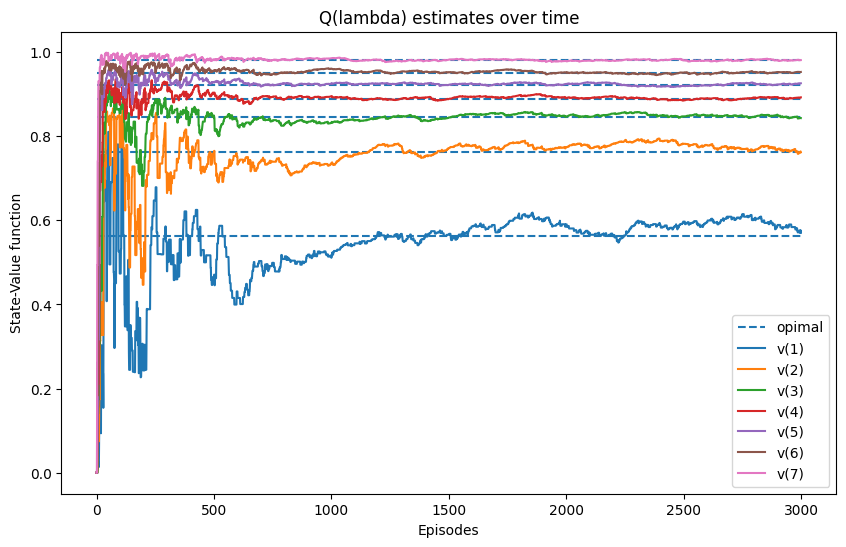

In [35]:
plt.figure(figsize=(10,6));
plt.hlines(optimal_v[1:8], 0, 3000, linestyle='--');
plt.plot(v_track_ql_lambda[:,1:8]);
plt.title('Q(lambda) estimates over time');
plt.ylabel('State-Value function');
plt.xlabel('Episodes');
plt.legend(legends);
plt.show();

Also in this case, by using eligibility traces to update not only the current state-action pair, but also past state-action pairs that contributed to the current reward, Q(lambda) can learn faster by assigning credit to prior states. However, the same observations on complexity and the need for tuning made for Sarsa(lambda) apply to Q(lambda) as well.

## Comparison

In order to compare the different algorithms, we can consider the state-value function estimation error as the mean absolute error across all estimates from their respective optimal. Take a look at how quickly Q-learning drops near zero, but also how double Q-learning gets to the lowest error first: 

In [36]:
def moving_average(a, n=100) :
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

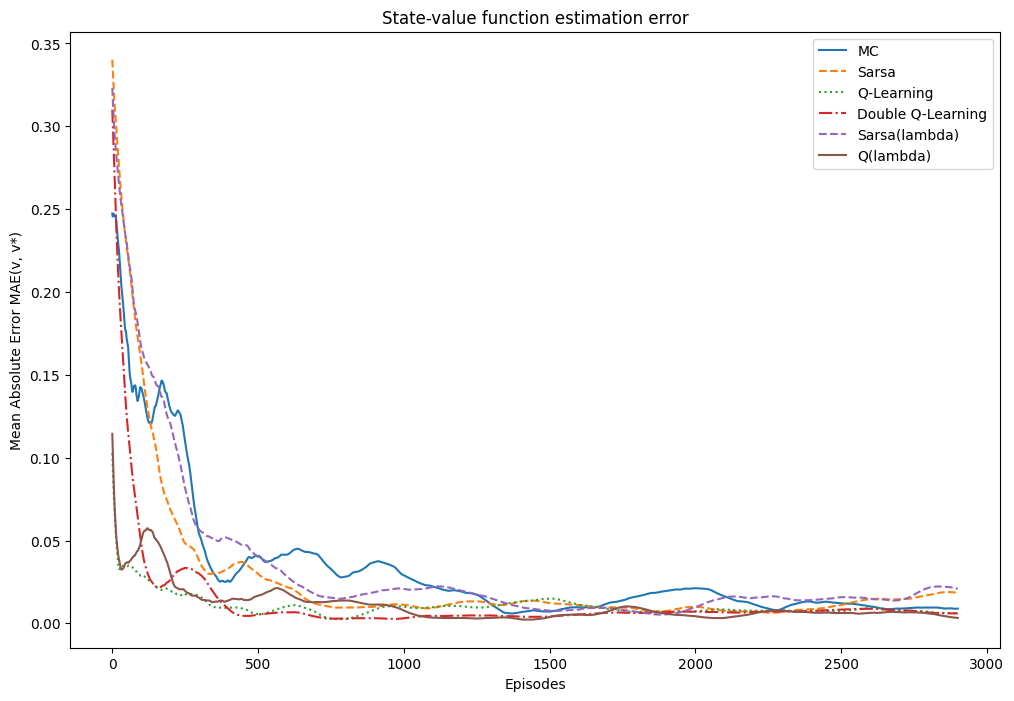

In [37]:
plt.figure(figsize=(12,8))
plt.plot(moving_average(np.mean(np.abs(v_track_mc - optimal_v), axis=1)), '-', label='MC');
plt.plot(moving_average(np.mean(np.abs(v_track_sarsa - optimal_v), axis=1)), '--', label='Sarsa');
plt.plot(moving_average(np.mean(np.abs(v_track_ql - optimal_v), axis=1)), ':', label='Q-Learning');
plt.plot(moving_average(np.mean(np.abs(v_track_dql - optimal_v), axis=1)), '-.', label='Double Q-Learning');
plt.plot(moving_average(np.mean(np.abs(v_track_sarsa_lambda - optimal_v), axis=1)), '--', label='Sarsa(lambda)');
plt.plot(moving_average(np.mean(np.abs(v_track_ql_lambda - optimal_v), axis=1)), '-', label='Q(lambda)');
plt.legend(loc=1, ncol=1);
plt.title('State-value function estimation error');
plt.xlabel('Episodes');
plt.ylabel('Mean Absolute Error MAE(v, v*)');
plt.show();

In the end, Monte Carlo is simple but slow and limited to episodic tasks; Sarsa is more conservative, focusing on actions based on the current policy, and works well when stability is needed; Q-learning aggressively learns the optimal policy but is prone to overestimation. Double Q-learning is a better alternative when stability is a concern, as it mitigates overestimation. Sarsa(lambda) and Q(lambda) provide a middle ground between learning speed and robustness by using eligibility traces, with Q(lmbda) being faster due to its off-policy nature. The choice of algorithm often depends on the specific environment and the need for stability, exploration, and learning speed.